<a href="https://colab.research.google.com/github/DRzaid-tech/MLREH2/blob/main/CareProjectZ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CARE to Compare: A real-world dataset for anomaly
detection in wind turbine data

Load the datasets :

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
from google.colab import drive
import os
import random
import matplotlib.pyplot as plt

# Mount Google Drive to access files
# drive.mount('/content/drive')
# /content/drive/MyDrive/CARE_To_Compare
# Define base paths for the datasets and output
BASE_PATH = '/content/drive/MyDrive/CARE_To_Compare'
OUT_PATH = '/content/drive/MyDrive/CARE_out'

# Define paths for the different wind farms
WIND_FARMS_PATHS = {
    "farm_a": os.path.join(BASE_PATH, 'Wind Farm A'),
    "farm_b": os.path.join(BASE_PATH, 'Wind Farm B'),
    "farm_c": os.path.join(BASE_PATH, 'Wind Farm C')
}

# Filenames for the event info and feature description
EVENT_INFO_FILENAME = "event_info.csv"
FEATURE_DESCRIPTION_FILENAME = "feature_description.csv"

def get_filename_without_extension(file_path: str) -> str:
    """Returns the filename without its extension."""
    return os.path.splitext(os.path.basename(file_path))[0]

def get_csv_files(path: str):
    """Returns a list of all CSV files in the given path."""
    return [os.path.join(path, f) for f in os.listdir(path) if f.endswith('.csv')]

def get_all_files_paths():
    """Returns a dictionary of all CSV file paths for each wind farm."""
    return {farm: get_csv_files(os.path.join(path, 'datasets')) for farm, path in WIND_FARMS_PATHS.items()}

def custom_get_files_paths(farms: list[str], n_to_read: list[int], randomize: bool, sequelize: bool = False):
    """
    Retrieves file paths for selected farms and specifies how many to read.

    Args:
        farms (list): List of farms to read files from.
        n_to_read (list): List of numbers specifying how many files to read from each farm.
        randomize (bool): Whether to randomly select files.

    Returns:
        dict: Selected file paths along with their normal behavior status.
    """
    if len(farms) != len(n_to_read):
        raise ValueError("farm_to_read and n_to_read must have the same length.")

    all_files_paths = get_all_files_paths()  # Get all available file paths
    selected_files_paths = {}

    for i, farm in enumerate(farms):
        if farm not in all_files_paths:
            print(f"Farm '{farm}' not found in available farms.")
            continue

        anomaly_event_ids_list = read_event_info(farm)[
            read_event_info(farm)['event_label'] == 'anomaly'
        ]['event_id'].astype(str).tolist()  # Get all anomaly event IDs

        farm_files = all_files_paths[farm]

        normal_files = [file_path for file_path in farm_files if get_filename_without_extension(file_path) not in anomaly_event_ids_list]
        anomaly_files = [file_path for file_path in farm_files if get_filename_without_extension(file_path) in anomaly_event_ids_list]


        if sequelize:
            # If we need to balance normal and anomaly files
            min_len = min(len(normal_files), len(anomaly_files))
            n_normal = min(n_to_read[i] // 2, min_len)
            n_anomaly = min(n_to_read[i] - n_normal, min_len)

            # Adjust in case there are no enough files
            if n_normal + n_anomaly < n_to_read[i]:
                extra_needed = n_to_read[i] - (n_normal + n_anomaly)
                if len(normal_files) > len(anomaly_files):
                    n_normal += extra_needed
                else:
                    n_anomaly += extra_needed

            selected_normal_files = normal_files[:n_normal]
            selected_anomaly_files = anomaly_files[:n_anomaly]

            selected_files = selected_normal_files + selected_anomaly_files

        else:
            # If we don't need to balance, just select the files normally
            if randomize:
                selected_files = random.sample(farm_files, min(n_to_read[i], len(farm_files)))
            else:
                selected_files = farm_files[:n_to_read[i]]

        selected_files_paths[farm] = [
            {
                "id": get_filename_without_extension(file_path),
                "has_normal_behavior": (get_filename_without_extension(file_path) not in anomaly_event_ids_list),
                "path": file_path
            }
            for file_path in selected_files
        ]

    return selected_files_paths

def subset_by_index(dataset, id1, id2, id_column='id'):
    """Returns a subset of the dataset between two IDs, inclusive."""
    if id1 not in dataset[id_column].values or id2 not in dataset[id_column].values:
        raise ValueError(f"Both id1 ({id1}) and id2 ({id2}) must exist in the dataset.")

    index1, index2 = dataset[dataset[id_column] == id1].index[0], dataset[dataset[id_column] == id2].index[0]

    if index1 > index2:
        raise ValueError("Index of id1 must be less than or equal to index of id2.")

    return dataset.iloc[index1:index2 + 1]  # Include index2

def split_dataset_by_index(dataset, id1, id2, id_column='id'):
    """
    Splits the dataset into two parts based on specified IDs and returns them in a dictionary.

    Parameters:
        dataset (pd.DataFrame): The dataset to split.
        id1 (int or str): The ID marking the start of the 'pred' subset.
        id2 (int or str): The ID marking the end of the 'pred' subset.
        id_column (str): The column name containing IDs. Default is 'id'.

    Returns:
        dict: A dictionary with 'train' and 'pred' DataFrames.
    """
    # Vérifier que les IDs existent
    if id1 not in dataset[id_column].values or id2 not in dataset[id_column].values:
        raise ValueError(f"Both id1 ({id1}) and id2 ({id2}) must exist in the dataset.")

    # Récupérer les index pour les ID donnés
    index1 = dataset[dataset[id_column] == id1].index[0]
    index2 = dataset[dataset[id_column] == id2].index[0]

    if index1 > index2:
        raise ValueError("Index of id1 must be less than or equal to index of id2.")

    # Diviser le DataFrame en deux parties
    train_set = dataset.iloc[:index1]  # Toutes les lignes avant index1
    pred_set = dataset.iloc[index1:index2 + 1]  # Lignes entre index1 et index2 inclus

    # Retourner les sous-ensembles dans un dictionnaire
    # TRAIN PRED
    return {"train": train_set, "pred": pred_set}


def combine_dataframes(dataframes_dict: dict[str, pd.DataFrame]):
    """Combines multiple DataFrames into a single DataFrame."""
    return pd.concat(list(dataframes_dict.values()), axis=0, join='outer', ignore_index=True)

def get_combined_event_info():
    """Combines event info DataFrames from all farms into a single DataFrame."""
    event_dataframes = []
    for farm in ["farm_a", "farm_b", "farm_c"]:
        event_info_df = read_event_info(farm)
        if event_info_df is not None and not event_info_df.empty:
            event_dataframes.append(event_info_df)

    return pd.concat(event_dataframes, ignore_index=True) if event_dataframes else pd.DataFrame()


Reading csv

In [ ]:
def read_feature_description(farm: str):
    """Reads the feature description file for the specified wind farm."""
    file_path = os.path.join(WIND_FARMS_PATHS[farm], FEATURE_DESCRIPTION_FILENAME)
    try:
        df = pd.read_csv(file_path, sep=';')
        print(f"Feature description file successfully read: {file_path}")
        return df
    except Exception as e:
        print(f"Error reading file {file_path}: {e}")
        return None

def read_event_info(farm: str):
    """Reads the event info file for the specified wind farm."""
    file_path = os.path.join(WIND_FARMS_PATHS[farm], EVENT_INFO_FILENAME)
    try:
        df = pd.read_csv(file_path, sep=';')
        print(f"Event info file successfully read: {file_path}")
        return df
    except Exception as e:
        print(f"Error reading file {file_path}: {e}")
        return None

def custom_read_csv(files_paths_dict: dict):
    """Reads multiple CSV files from the provided paths and returns a mapping of file IDs to DataFrames."""
    dataframes_dict = {}

    for farm, files in files_paths_dict.items():
        for file_info in files:
            file_path = file_info.get("path")
            file_id = get_filename_without_extension(file_path)

            try:
                df = pd.read_csv(file_path, sep=';')
                dataframes_dict[file_id] = df
                print(f"File successfully read: {file_path}")
            except Exception as e:
                print(f"Error reading file {file_path}: {e}")

    return dataframes_dict

def custom_read_csv_subsets(dataframes_dict: dict, event_info: pd.DataFrame = None):
    """Creates subsets of DataFrames based on event start and end IDs."""
    if event_info is None:
        event_info = get_combined_event_info()

    subset_dataframes_dict = {}

    for file_id, df in dataframes_dict.items():
        event_row = event_info[event_info['event_id'].astype(str) == file_id]

        if not event_row.empty:
            event_start_id = int(event_row['event_start_id'].values[0])
            event_end_id = int(event_row['event_end_id'].values[0])
            event_label = event_row['event_label'].values[0]

            # print(f"Original size of DataFrame for event_id {file_id}: {df.shape}")

            try:
                subset = split_dataset_by_index(df, event_start_id, event_end_id)
                # SEPARATION PREDICTION ET TRAINING
                subset_dataframes_dict[file_id] = {
                    "train": subset.get("train"),
                    "pred": subset.get("pred"),
                    "label": event_label
                }
                # print(f"Subset successfully created for event_id: {file_id}")
            except ValueError as e:
                print(f"Error creating subset for event_id {file_id}: {e}")
        else:
            print(f"No matching event found for event_id: {file_id}")

    return subset_dataframes_dict


def label_data(dataframes_dict: dict, event_info: pd.DataFrame = None):
    """
    Associe des labels (anomaly ou normal) aux données SCADA basées sur les événements dans event_info.
    """
    if event_info is None:
        event_info = get_combined_event_info()
    labeled_dataframes_dict = {}
    # récupère le event_info

    for file_id, df in dataframes_dict.items():
        # utilise le file_id pour savoir de quel fichier csv on traite

        # récupère la ligne correspondant au dataframe traité dans la boucle
        event_row = event_info[event_info['event_id'].astype(str) == file_id]

        if not event_row.empty:
            # Obtenir les IDs de début et de fin de l'événement
            event_start_id = int(event_row['event_start_id'].values[0])
            event_end_id = int(event_row['event_end_id'].values[0])
            label = event_row['event_label'].values[0]  # 'anomaly' ou 'normal'

            print(f"Labeling DataFrame for event_id {file_id} with {label}.")

            try:
                # Créer un sous-ensemble correspondant à la période de l'événement
                subset = subset_by_index(df, event_start_id, event_end_id).copy()

                # Ajouter une colonne de labels avec 'anomaly' ou 'normal'
                subset.loc[:, 'label'] = label

                # Sauvegarder les données labelisées
                labeled_dataframes_dict[file_id] = subset
                print(f"Data labeled for event_id: {file_id}")

            except ValueError as e:
                print(f"Error labeling data for event_id {file_id}: {e}")
        else:
            print(f"No matching event found for event_id: {file_id}")

    return labeled_dataframes_dict

**Outliers**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_fancy_boxplots(df, columns=None, figsize=(20, 10), title="Box Plot for Outlier Detection"):
    """
    Generate elegant box plots with red-colored outliers for given numeric columns.

    Parameters:
    -----------
    df : pd.DataFrame
        Input DataFrame containing numeric features.
    columns : list or None
        Specific list of columns to plot. If None, all numeric columns are used.
    figsize : tuple
        Size of the entire figure (width, height).
    title : str
        Title of the entire plot.
    """
    # Filter numeric columns
    if columns is None:
        columns = df.select_dtypes(include='number').columns.tolist()

    num_cols = len(columns)
    if num_cols == 0:
        print("No numeric columns found.")
        return

    # Plot styling
    sns.set(style="whitegrid")
    palette = sns.color_palette("pastel")

    # Create subplots
    fig, axes = plt.subplots(1, num_cols, figsize=(figsize[0]*min(1, num_cols/4), figsize[1]), squeeze=False)
    fig.suptitle(title, fontsize=18, weight='bold', y=1.05)

    for i, col in enumerate(columns):
        ax = axes[0, i]
        sns.boxplot(
            y=df[col],
            ax=ax,
            width=0.3,
            fliersize=5,
            flierprops=dict(marker='o', color='red', alpha=0.6, markersize=6),
            boxprops=dict(facecolor=palette[i % len(palette)], linewidth=1.5),
            medianprops=dict(color='black', linewidth=2),
            whiskerprops=dict(linewidth=1.5),
            capprops=dict(linewidth=1.5)
        )
        ax.set_title(f"{col}", fontsize=14)
        ax.set_xticklabels(rotation=90)  # Hide x-axis labels
        ax.set_ylabel("")  # Hide individual y-axis labels for clarity

    plt.tight_layout()
    plt.show()


In [ ]:
def Pairs_Analysis(X_train, farm_name, selected_features, target_values):
    """
    Generates a pairplot for selected features from the input dataset,
    colored by the target values for outlier or cluster visualization.

    Parameters:
    - X_train: pd.DataFrame
        The training dataset containing feature columns.
    - farm_name: str
        The name of the wind farm for plot titling.
    - selected_features: list or pd.Index
        List of selected feature names (columns) to include in the plot.
    - target_values: pd.Series or array-like
        Target values used to color the data points (e.g., class or status ID).
    """

    # Combine features and target into a single DataFrame
    df_plot = X_train[selected_features].copy()
    df_plot['Target'] = target_values.values if hasattr(target_values, 'values') else target_values

    # Plot pairplot
    sns.pairplot(df_plot, hue='Target', palette='Set1', corner=True, diag_kind='kde', plot_kws={'alpha': 0.7, 's': 40})
    plt.suptitle(f'Pairplots  and Relationship Analysis - {farm_name}', fontsize=16, y=1.02)
    plt.show()


In [ ]:
!pip install shap

# FARM A

Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/event_info.csv
farm_a :
{'id': '14', 'has_normal_behavior': True, 'path': '/content/drive/MyDrive/CARE_To_Compare/Wind Farm A/datasets/14.csv'}
{'id': '22', 'has_normal_behavior': False, 'path': '/content/drive/MyDrive/CARE_To_Compare/Wind Farm A/datasets/22.csv'}
{'id': '71', 'has_normal_behavior': True, 'path': '/content/drive/MyDrive/CARE_To_Compare/Wind Farm A/datasets/71.csv'}
{'id': '25', 'has_normal_behavior': True, 'path': '/content/drive/MyDrive/CARE_To_Compare/Wind Farm A/datasets/25.csv'}
{'id': '13', 'has_normal_behavior': True, 'path': '/content/drive/MyDrive/CARE_To_Compare/Wind Farm A/datasets/13.csv'}
{'id': '17', 'has_normal_behavior': True, 'path': '/content/drive/MyDrive/CARE_To_Compare/Wind Farm A/datasets/17.csv'}
{'id': '51', 'has_normal_behavior': True, 'path': '/content/drive/My

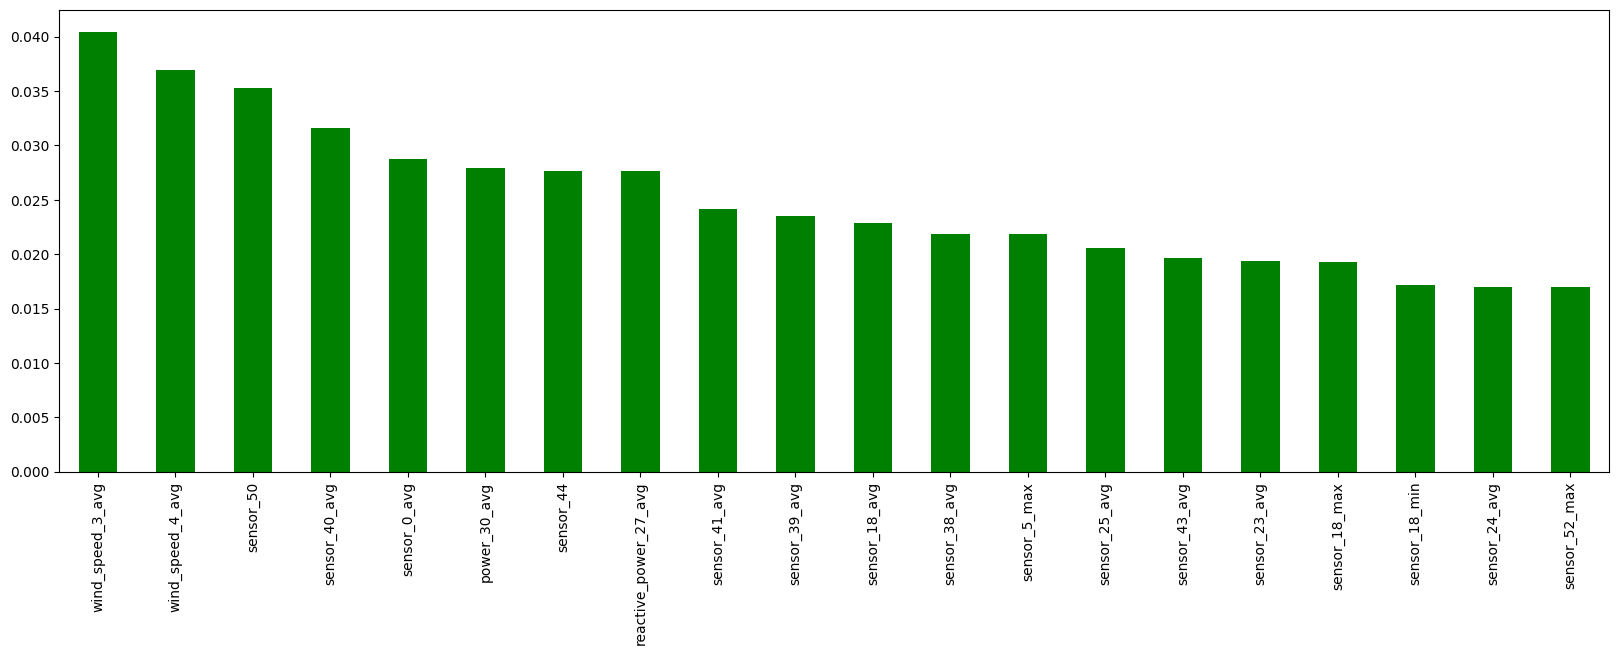

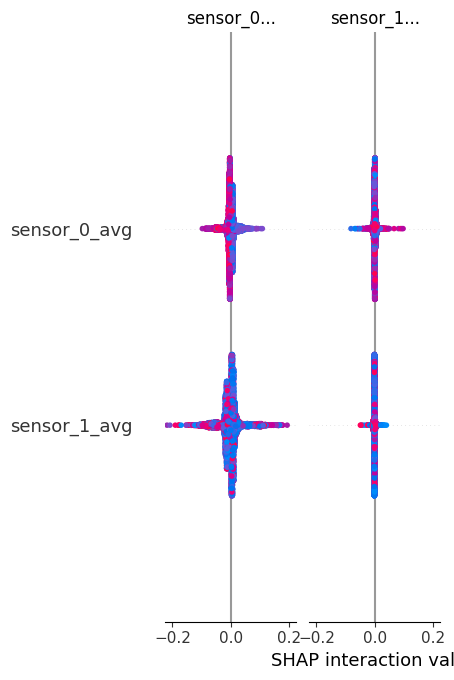

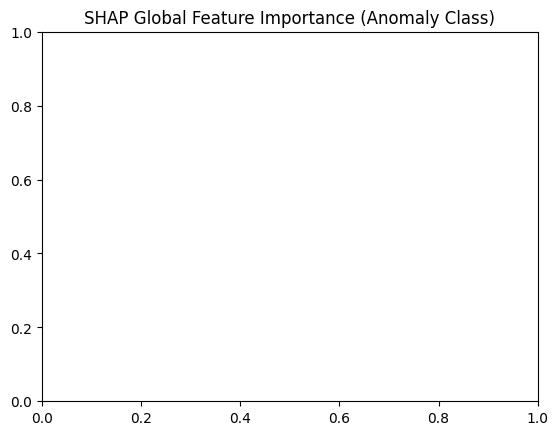

'\nScores de validation croisée (5-fold): [0.98058252 0.97666169 0.98020911 0.97666169 0.97684839]\nMoyenne des scores de validation croisée: 0.9781926811053024\n\nPrécision du modèle : 0.9885772538358993\nRapport de classification :\n               precision    recall  f1-score   support\n\n       False       0.98      0.96      0.97      6489\n        True       0.99      0.99      0.99     31768\n\n    accuracy                           0.99     38257\n   macro avg       0.98      0.98      0.98     38257\nweighted avg       0.99      0.99      0.99     38257\n'

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score
import shap
# Main execution
farm_to_read = ["farm_a"]
n_to_read = [22]  # Number of files to read from each farm
randomize = True  # Whether to randomize selection

# Retrieve file paths based on specified farms and conditions
files_paths = custom_get_files_paths(farm_to_read, n_to_read, randomize)

# Read and display selected files
for farm, files in files_paths.items():
    print(farm, ":")
    for file in files:
        print(file)
print()

# Read each selected CSV file into DataFrames
dataframes = custom_read_csv(files_paths)

# Create subsets based on event info
data_dict = custom_read_csv_subsets(dataframes)

# Étape 1 : Préparation des données
dataframes = []
labels = []
dataframes_train = []
dataframes_pred = []

for item in data_dict.values():
    df_train = item['train']
    df_pred = item['pred']
    label = item['label']

    # Ajouter l'étiquette pour chaque ligne du DataFrame train et pred
    df_train = df_train.copy()
    df_pred = df_pred.copy()
    df_train['label'] = label
    df_pred['label'] = label

    dataframes_train.append(df_train)
    dataframes_pred.append(df_pred)

# Combiner les DataFrames
combined_df_train = pd.concat(dataframes_train, ignore_index=True)
combined_df_pred = pd.concat(dataframes_pred, ignore_index=True)

combined_df_train = combined_df_train.sample(frac=0.3, random_state=42)
combined_df_train = combined_df_pred.sample(frac=0.7, random_state=42)

# Supprimer les espaces autour des noms de colonnes
combined_df_train.columns = combined_df_train.columns.str.strip()
combined_df_pred.columns = combined_df_pred.columns.str.strip()

# Filtrer pour garder uniquement les lignes avec status_type_id 0, 1, 3, 4, ou 5
valid_status_ids = [0, 1, 3, 4, 5]
filtered_train_df = combined_df_train[combined_df_train['status_type_id'].isin(valid_status_ids)]
filtered_pred_df = combined_df_pred[combined_df_pred['status_type_id'].isin(valid_status_ids)]

# Créer les labels : True pour 'anomaly' et False pour 'normal'
y_train = filtered_train_df['status_type_id'].apply(lambda x: True if x == 0 else False)
y_test = filtered_pred_df['status_type_id'].apply(lambda x: True if x == 0 else False)

# Supprimer les colonnes inutiles avant de sélectionner les colonnes numériques
X_train = filtered_train_df.drop(['time_stamp', 'status_type_id', 'asset_id', 'id', 'label'], axis=1)
X_test = filtered_pred_df.drop(['time_stamp', 'status_type_id', 'asset_id', 'id', 'label'], axis=1)

# Sélectionner les colonnes numériques restantes pour les caractéristiques (X)
X_train = X_train.select_dtypes(include=['float64', 'int64'])
X_test = X_test.select_dtypes(include=['float64', 'int64'])

# Entraîner un modèle Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, n_jobs=-1)
print("Scores de validation croisée (5-fold):", cv_scores)
print("Moyenne des scores de validation croisée:", cv_scores.mean())

# Évaluer le modèle, en affichant l'importance des caractéristiques
feature_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)

# Limiter l'affichage des importances des caractéristiques
top_n = 20  # Afficher seulement les 10 plus importantes
feature_importances[:top_n].plot(kind='bar', figsize=(20, 6),color='green')
# plt.title('Features Importance Analysis: Wind Farm A')
# plt.xlabel('Features')
# plt.ylabel('Importance')
# plt.grid(True)
# plt.show()
# # Optionnel : Faire des prédictions et évaluer la performance
# y_pred = rf.predict(X_test)
explainer = shap.TreeExplainer(rf)

# Compute SHAP values for a subset of the test set
# Selecting a smaller number of samples for SHAP computation for performance
X_test_subset = X_test.sample(n=10000, random_state=42) if len(X_test) > 10000 else X_test
shap_values = explainer.shap_values(X_test_subset)


# Summary plot (global importance)
shap.summary_plot(shap_values, X_test_subset)
plt.title("SHAP Global Feature Importance (Anomaly Class)")
plt.show()

# # Summary plot (beeswarm): better for full distribution of impacts
# shap.summary_plot(shap_values[1], X_test_subset[1])
# plt.title("SHAP Beeswarm Plot: Feature Impact on Anomaly Prediction")
# plt.show()

# # Optional: Explain a single prediction (e.g., 5th test sample)
# index_to_explain = 5
# shap.force_plot(
#     explainer.expected_value[1],
#     shap_values[1][index_to_explain, :],
#     X_test_subset.iloc[index_to_explain, :],
#     matplotlib=True
# )
# # print("Précision du modèle :", accuracy_score(y_test, y_pred))
# print("Rapport de classification :\n", classification_report(y_test, y_pred))

'''
Scores de validation croisée (5-fold): [0.98058252 0.97666169 0.98020911 0.97666169 0.97684839]
Moyenne des scores de validation croisée: 0.9781926811053024

Précision du modèle : 0.9885772538358993
Rapport de classification :
               precision    recall  f1-score   support

       False       0.98      0.96      0.97      6489
        True       0.99      0.99      0.99     31768

    accuracy                           0.99     38257
   macro avg       0.98      0.98      0.98     38257
weighted avg       0.99      0.99      0.99     38257
'''

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
def outliers_Analysis(Data,WF,Features):
# Apply MinMaxScaler on top_n features
 top_features =  Features # Get top N feature names
 X_scaled = pd.DataFrame(
    MinMaxScaler().fit_transform(X_train[top_features]),
    columns=top_features,
    index=X_train.index
 )

# Plot boxplot
 plt.figure(figsize=(20, 8))
 sns.boxplot(data=X_scaled)
 plt.title('Features Importance Analysis: '+WF)
 plt.yscale('log')  # Optional: only if values span orders of magnitude
 plt.xticks(fontsize=16, rotation=90)
 plt.yticks(fontsize=16)
 plt.grid()
 plt.show()
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def correlation_heatmap(X_train, farm_name, selected_features):
    """
    Generate a Pearson correlation heatmap for the selected features
    with a green-glassy aesthetic.

    Parameters
    ----------
    X_train : pd.DataFrame
        Training dataset containing features.
    farm_name : str
        Name of the wind farm (used in plot title).
    selected_features : list or index
        Features to include in the correlation heatmap.
    """

    # Subset the dataframe
    data = X_train[selected_features]

    # Compute Pearson correlation matrix
    corr = data.corr(method='pearson')

    # Plot settings
    plt.figure(figsize=(12, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))  # mask upper triangle

    # Custom green-glassy colormap
    cmap = sns.color_palette("Greens", as_cmap=True)

    # Create heatmap
    sns.heatmap(
        corr,
        mask=mask,
        cmap=cmap,
        annot=True,
        fmt=".2f",
        linewidths=0.8,
        cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"},
        vmin=-1,
        vmax=1,
        square=True
    )

    # Title styling
    plt.title(f"Pearson Correlation Heatmap - {farm_name}", fontsize=14, fontweight='bold', color="#06402B")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()
# outliers_Analysis(X_train,'Wind Farm A',feature_importances[:top_n].index)
correlation_heatmap(X_train, 'Wind Farm A', feature_importances[:top_n].index)

In [ ]:
# Pairs_Analysis(X_train,'Wind Farm A',feature_importances[:7].index, y_train)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Paramètres à tester
param_grid = {
    'n_estimators': [50],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

# Grid Search avec validation croisée
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# Afficher les meilleurs paramètres
print("Meilleurs paramètres : ", grid_search.best_params_)
"""
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Meilleurs paramètres :  {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
"""

In [ ]:
# Réentraîner le modèle avec les meilleurs hyperparamètres
best_rf = RandomForestClassifier(
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=50,
    random_state=42
)

# Entraîner sur l'ensemble d'entraînement complet
best_rf.fit(X_train, y_train)


# Prédire avec le modèle optimisé
y_pred_optimized = best_rf.predict(X_test)

# Afficher les métriques de performance
print("Précision du modèle optimisé :", accuracy_score(y_test, y_pred_optimized))
print("Rapport de classification (modèle optimisé) :\n", classification_report(y_test, y_pred_optimized))

'''
Précision du modèle optimisé : 0.9879237786548867
Rapport de classification (modèle optimisé) :
               precision    recall  f1-score   support

       False       0.97      0.96      0.96      6489
        True       0.99      0.99      0.99     31768

    accuracy                           0.99     38257
   macro avg       0.98      0.97      0.98     38257
weighted avg       0.99      0.99      0.99     38257
'''


In [ ]:
import joblib

# Sauvegarder le modèle optimisé
joblib.dump(best_rf, 'modele_optimise_random_forest.pkl')


In [ ]:
import joblib
from sklearn.metrics import classification_report, accuracy_score

farm_to_read = ["farm_a"]
n_to_read = [1]  # Number of files to read from each farm
randomize = False  # Whether to randomize selection

# Retrieve file paths based on specified farms and conditions
files_paths_new = custom_get_files_paths(farm_to_read, n_to_read, randomize)
print(files_paths_new)
file_path = files_paths_new.get("farm_a")[0].get("path")

for farm, files in files_paths_new.items():
    print(farm, ":")
    for file in files:
        print(file)
print()

new_data = pd.read_csv(file_path, sep=';')

# Prétraitement des nouvelles données
X_new = new_data.drop(['time_stamp', 'status_type_id', 'asset_id', 'id'], axis=1)
X_new = X_new.select_dtypes(include=['float64', 'int64'])  # Garder seulement les colonnes numériques
y_true_new = new_data['status_type_id'].apply(lambda x: True if x == 0 else False)

# Charger le modèle
best_rf_loaded = joblib.load('modele_optimise_random_forest.pkl')

# Prédire avec le modèle chargé
y_pred_new = best_rf_loaded.predict(X_new)
print("Précision sur les nouvelles données :", accuracy_score(y_true_new, y_pred_new))
print("Rapport de classification sur les nouvelles données:\n", classification_report(y_true_new, y_pred_new))


# FARM B

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

farm_to_read = ["farm_b"]
n_to_read = [5]  # Number of files to read from each farm
randomize = True  # Whether to randomize selection

# Retrieve file paths based on specified farms and conditions
files_paths = custom_get_files_paths(farm_to_read, n_to_read, randomize)

# Read and display selected files
for farm, files in files_paths.items():
    print(farm, ":")
    for file in files:
        print(file)
print()

# Read each selected CSV file into DataFrames
dataframes = custom_read_csv(files_paths)

# Create subsets based on event info
data_dict = custom_read_csv_subsets(dataframes)

# Étape 1 : Préparation des données
dataframes = []
labels = []
dataframes_train = []
dataframes_pred = []

for item in data_dict.values():
    df_train = item['train']
    df_pred = item['pred']
    label = item['label']

    # Ajouter l'étiquette pour chaque ligne du DataFrame train et pred
    df_train = df_train.copy()
    df_pred = df_pred.copy()
    df_train['label'] = label
    df_pred['label'] = label

    dataframes_train.append(df_train)
    dataframes_pred.append(df_pred)

# Combiner les DataFrames
combined_df_train = pd.concat(dataframes_train, ignore_index=True)
combined_df_pred = pd.concat(dataframes_pred, ignore_index=True)

combined_df_train = combined_df_train.sample(frac=0.3, random_state=42)
combined_df_train = combined_df_pred.sample(frac=0.7, random_state=42)

# Supprimer les espaces autour des noms de colonnes
combined_df_train.columns = combined_df_train.columns.str.strip()
combined_df_pred.columns = combined_df_pred.columns.str.strip()

# Filtrer pour garder uniquement les lignes avec status_type_id 0, 1, 3, 4, ou 5
valid_status_ids = [0, 1, 3, 4, 5]
filtered_train_df = combined_df_train[combined_df_train['status_type_id'].isin(valid_status_ids)]
filtered_pred_df = combined_df_pred[combined_df_pred['status_type_id'].isin(valid_status_ids)]

# Créer les labels : True pour 'anomaly' et False pour 'normal'
y_train = filtered_train_df['status_type_id'].apply(lambda x: True if x == 0 else False)
y_test = filtered_pred_df['status_type_id'].apply(lambda x: True if x == 0 else False)

# Supprimer les colonnes inutiles avant de sélectionner les colonnes numériques
X_train = filtered_train_df.drop(['time_stamp', 'status_type_id', 'asset_id', 'id', 'label'], axis=1)
X_test = filtered_pred_df.drop(['time_stamp', 'status_type_id', 'asset_id', 'id', 'label'], axis=1)

# Sélectionner les colonnes numériques restantes pour les caractéristiques (X)
X_train = X_train.select_dtypes(include=['float64', 'int64'])
X_test = X_test.select_dtypes(include=['float64', 'int64'])

# Diviser les données en ensembles d'entraînement et de test
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Entraîner un modèle Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

cv_scores = cross_val_score(rf, X_train, y_train, cv=5, n_jobs=-1)
print("Scores de validation croisée (5-fold):", cv_scores)
print("Moyenne des scores de validation croisée:", cv_scores.mean())

# Évaluer le modèle, en affichant l'importance des caractéristiques
feature_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)

# Limiter l'affichage des importances des caractéristiques
top_n = 20  # Afficher seulement les 10 plus importantes
feature_importances[:top_n].plot(kind='bar', figsize=(20, 6),color='green')
plt.title('Features Importance Analysis: Wind Farm B')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.grid(True)
plt.show()

# Optionnel : Faire des prédictions et évaluer la performance
y_pred = rf.predict(X_test)

print("Précision du modèle :", accuracy_score(y_test, y_pred))
print("Rapport de classification :\n", classification_report(y_test, y_pred))

'''
Précision du modèle : 0.9995837149279827
Rapport de classification :
               precision    recall  f1-score   support

       False       1.00      0.99      0.99       342
        True       1.00      1.00      1.00     11669

    accuracy                           1.00     12011
   macro avg       1.00      0.99      1.00     12011
weighted avg       1.00      1.00      1.00     12011
'''




In [ ]:
# outliers_Analysis(X_train,'Wind Farm B',feature_importances[:top_n].index)
# Pairs_Analysis(X_train,'Wind Farm B',feature_importances[:7].index, y_train)
correlation_heatmap(X_train, 'Wind Farm B', feature_importances[:top_n].index)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Paramètres à tester
param_grid = {
    'n_estimators': [50],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

# Grid Search avec validation croisée
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# Afficher les meilleurs paramètres
print("Meilleurs paramètres : ", grid_search.best_params_)
"""
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Meilleurs paramètres :  {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}
"""

In [ ]:
# Réentraîner le modèle avec les meilleurs hyperparamètres
best_rf = RandomForestClassifier(
    max_depth=20,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=50,
    random_state=42
)

# Entraîner sur l'ensemble d'entraînement complet
best_rf.fit(X_train, y_train)


# Prédire avec le modèle optimisé
y_pred_optimized = best_rf.predict(X_test)

# Afficher les métriques de performance
print("Précision du modèle optimisé :", accuracy_score(y_test, y_pred_optimized))
print("Rapport de classification (modèle optimisé) :\n", classification_report(y_test, y_pred_optimized))

'''
Précision du modèle optimisé : 0.9995837149279827
Rapport de classification (modèle optimisé) :
               precision    recall  f1-score   support

       False       0.99      0.99      0.99       342
        True       1.00      1.00      1.00     11669

    accuracy                           1.00     12011
   macro avg       1.00      1.00      1.00     12011
weighted avg       1.00      1.00      1.00     12011
'''


In [ ]:
import joblib

# Sauvegarder le modèle optimisé
joblib.dump(best_rf, 'modele_optimise_random_forest.pkl')


# FARM C

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

farm_to_read = ["farm_c"]
n_to_read = [5]  # Number of files to read from each farm
randomize = True  # Whether to randomize selection

# Retrieve file paths based on specified farms and conditions
files_paths = custom_get_files_paths(farm_to_read, n_to_read, randomize)

# Read and display selected files
for farm, files in files_paths.items():
    print(farm, ":")
    for file in files:
        print(file)
print()

# Read each selected CSV file into DataFrames
dataframes = custom_read_csv(files_paths)

# Create subsets based on event info
data_dict = custom_read_csv_subsets(dataframes)

# Étape 1 : Préparation des données
dataframes = []
labels = []
dataframes_train = []
dataframes_pred = []

for item in data_dict.values():
    df_train = item['train']
    df_pred = item['pred']
    label = item['label']

    # Ajouter l'étiquette pour chaque ligne du DataFrame train et pred
    df_train = df_train.copy()
    df_pred = df_pred.copy()
    df_train['label'] = label
    df_pred['label'] = label

    dataframes_train.append(df_train)
    dataframes_pred.append(df_pred)

# Combiner les DataFrames
combined_df_train = pd.concat(dataframes_train, ignore_index=True)
combined_df_pred = pd.concat(dataframes_pred, ignore_index=True)

combined_df_train = combined_df_train.sample(frac=0.1, random_state=42)
combined_df_train = combined_df_pred.sample(frac=0.5, random_state=42)

# Supprimer les espaces autour des noms de colonnes
combined_df_train.columns = combined_df_train.columns.str.strip()
combined_df_pred.columns = combined_df_pred.columns.str.strip()

# Filtrer pour garder uniquement les lignes avec status_type_id 0, 1, 3, 4, ou 5
valid_status_ids = [0, 1, 3, 4, 5]
filtered_train_df = combined_df_train[combined_df_train['status_type_id'].isin(valid_status_ids)]
filtered_pred_df = combined_df_pred[combined_df_pred['status_type_id'].isin(valid_status_ids)]

# Créer les labels : True pour 'anomaly' et False pour 'normal'
y_train = filtered_train_df['status_type_id'].apply(lambda x: True if x == 0 else False)
y_test = filtered_pred_df['status_type_id'].apply(lambda x: True if x == 0 else False)

# Supprimer les colonnes inutiles avant de sélectionner les colonnes numériques
X_train = filtered_train_df.drop(['time_stamp', 'status_type_id', 'asset_id', 'id', 'label'], axis=1)
X_test = filtered_pred_df.drop(['time_stamp', 'status_type_id', 'asset_id', 'id', 'label'], axis=1)

# Sélectionner les colonnes numériques restantes pour les caractéristiques (X)
X_train = X_train.select_dtypes(include=['float64', 'int64'])
X_test = X_test.select_dtypes(include=['float64', 'int64'])

# Diviser les données en ensembles d'entraînement et de test
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Entraîner un modèle Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Évaluer le modèle, en affichant l'importance des caractéristiques
feature_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)

# Limiter l'affichage des importances des caractéristiques
top_n = 20  # Afficher seulement les 10 plus importantes
feature_importances[:top_n].plot(kind='bar', figsize=(20, 8),color='green')
plt.title('Features Importance Analysis: Wind Farm C')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.grid(True)
plt.show()

# Optionnel : Faire des prédictions et évaluer la performance
y_pred = rf.predict(X_test)

print("Précision du modèle :", accuracy_score(y_test, y_pred))
print("Rapport de classification :\n", classification_report(y_test, y_pred))

"""
Précision du modèle : 0.9974387527839643
Rapport de classification :
               precision    recall  f1-score   support

       False       1.00      0.99      1.00      3176
        True       1.00      1.00      1.00      5804

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980
"""

In [ ]:
#outliers_Analysis(X_train,'Wind Farm C',feature_importances[:top_n].index)
# Pairs_Analysis(X_train,'Wind Farm C',feature_importances[:7].index, y_train)
correlation_heatmap(X_train, 'Wind Farm C', feature_importances[:top_n].index)

# **EvALUATION**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Paramètres à tester
param_grid = {
    'n_estimators': [50],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

# Grid Search avec validation croisée
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# Afficher les meilleurs paramètres
print("Meilleurs paramètres : ", grid_search.best_params_)

"""
Meilleurs paramètres :  {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
"""

In [ ]:
# Réentraîner le modèle avec les meilleurs hyperparamètres
best_rf = RandomForestClassifier(
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=50,
    random_state=42
)

# Entraîner sur l'ensemble d'entraînement complet
best_rf.fit(X_train, y_train)


# Prédire avec le modèle optimisé
y_pred_optimized = best_rf.predict(X_test)

# Afficher les métriques de performance
print("Précision du modèle optimisé :", accuracy_score(y_test, y_pred_optimized))
print("Rapport de classification (modèle optimisé) :\n", classification_report(y_test, y_pred_optimized))

"""
Précision du modèle optimisé : 0.9974387527839643
Rapport de classification (modèle optimisé) :
               precision    recall  f1-score   support

       False       1.00      0.99      1.00      3176
        True       1.00      1.00      1.00      5804

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980
"""


In [ ]:
import joblib
# Sauvegarder le modèle optimisé
joblib.dump(best_rf, 'modele_optimise_random_forest.pkl')


NameError: name 'best_rf' is not defined

In [ ]:
import shap
def explain_shap(model,X_test,columns):
 explainer = shap.TreeExplainer(model)
    # Compute SHAP values for a subset of the test set
    # Selecting a smaller number of samples for SHAP computation for performance
 #X_test_subset = X_test.sample(n=10000, random_state=42) if len(X_test) > 10000 else X_test
 shap_values = explainer.shap_values(X_test)


# Summary plot (global importance)
 shap.summary_plot(shap_values, X_test,feature_names=columns)
 plt.title("SHAP Global Feature Importance (Anomaly Class)")
 plt.show()

#  # Summary plot (beeswarm): better for full distribution of impacts
#  shap.summary_plot(shap_values[1], X_test_subset[1],feature_names=columns)
#  plt.title("SHAP Beeswarm Plot: Feature Impact on Anomaly Prediction")
#  plt.show()

# # # Optional: Explain a single prediction (e.g., 5th test sample)
#  index_to_explain = 5
#  shap.force_plot(
#      explainer.expected_value[1],
#      shap_values[1][index_to_explain, :],
#      X_test_subset.iloc[index_to_explain, :],
#      matplotlib=True,feature_names=columns,
#                   )

# Fonctions Entrainement modele

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def load_and_preprocess_data(farm_to_read, n_to_read, randomize=True):
    # Récupérer les chemins des fichiers
    files_paths = custom_get_files_paths(farm_to_read, n_to_read, randomize)

    # Lire les fichiers CSV dans des DataFrames
    dataframes = custom_read_csv(files_paths)

    # Créer des sous-ensembles basés sur les informations d'événement
    data_dict = custom_read_csv_subsets(dataframes)

    # Initialiser des listes pour stocker les DataFrames d'entraînement et de prédiction
    dataframes_train = []
    dataframes_pred = []

    # Préparer les données en ajoutant les labels
    for item in data_dict.values():
        df_train = item['train']
        df_pred = item['pred']
        label = item['label']

        # Ajouter l'étiquette pour chaque ligne du DataFrame train et pred
        df_train = df_train.copy()
        df_pred = df_pred.copy()

        # Utiliser .loc pour ajouter la colonne 'label'
        df_train.loc[:, 'label'] = label
        df_pred.loc[:, 'label'] = label

        dataframes_train.append(df_train)
        dataframes_pred.append(df_pred)

    # Combiner les DataFrames d'entraînement et de prédiction
    print("combination des dataframes ...")
    combined_df_train = pd.concat(dataframes_train, ignore_index=True)
    combined_df_pred = pd.concat(dataframes_pred, ignore_index=True)

    # Échantillonner les DataFrames (30% train, 70% pred)
    print("samplage ...")
    combined_df_train = combined_df_train.sample(frac=0.3, random_state=42)
    combined_df_pred = combined_df_pred.sample(frac=0.7, random_state=42)

    # Nettoyer les noms de colonnes
    print("nettoyage ...")
    combined_df_train.columns = combined_df_train.columns.str.strip()
    combined_df_pred.columns = combined_df_pred.columns.str.strip()

    # Filtrer les données pour garder uniquement les lignes avec des 'status_type_id' valides
    print("filtrage ...")
    valid_status_ids = [0, 1, 3, 4, 5]
    filtered_train_df = combined_df_train[combined_df_train['status_type_id'].isin(valid_status_ids)]
    filtered_pred_df = combined_df_pred[combined_df_pred['status_type_id'].isin(valid_status_ids)]

    # Créer les labels
    print("création labels ...")
    y_train = filtered_train_df['status_type_id'].apply(lambda x: True if x == 0 else False)
    y_test = filtered_pred_df['status_type_id'].apply(lambda x: True if x == 0 else False)

    # Supprimer les colonnes inutiles pour l'entraînement
    print("suppression colonnes inutiles ...")
    X_train = filtered_train_df.drop(['time_stamp', 'status_type_id', 'asset_id', 'id', 'label'], axis=1)
    X_test = filtered_pred_df.drop(['time_stamp', 'status_type_id', 'asset_id', 'id', 'label'], axis=1)

    # Sélectionner les colonnes numériques restantes
    print("sélection des autres colonnes numériques ...")
    X_train = X_train.select_dtypes(include=['float64', 'int64'])
    X_test = X_test.select_dtypes(include=['float64', 'int64'])

    return X_train, X_test, y_train, y_test

def train_random_forest(X_train, y_train):
    # Entraîner un modèle Random Forest
    rf = RandomForestClassifier(
        max_depth=None,
        min_samples_leaf=1,
        min_samples_split=2,
        n_estimators=50,
        random_state=42
    )
    rf.fit(X_train, y_train)

    # # Validation croisée
    # print("validation croisée ...")
    # cv_scores = cross_val_score(rf, X_train, y_train, cv=5, n_jobs=-1)
    # print("Scores de validation croisée (5-fold):", cv_scores)
    # print("Moyenne des scores de validation croisée:", cv_scores.mean())

    return rf

def plot_feature_importance(rf, X_train):
    # Afficher l'importance des caractéristiques
    feature_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
    feature_importances = feature_importances.sort_values(ascending=False)

    # Limiter l'affichage des importances des caractéristiques
    top_n = 20  # Afficher les 20 plus importantes
    feature_importances[:top_n].plot(kind='bar', figsize=(20, 6))
    plt.title('Importance des caractéristiques (Random Forest)')
    plt.xlabel('Caractéristiques')
    plt.ylabel('Importance')
    plt.show()

def evaluate_model(rf, X_test, y_test):
    # Faire des prédictions sur les données de test
    y_pred = rf.predict(X_test)

    # Calcul des métriques
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary')  # pour une classification binaire
    recall = recall_score(y_test, y_pred, average='binary')  # pour une classification binaire
    f1 = f1_score(y_test, y_pred, average='binary')  # pour une classification binaire

    # Affichage des résultats
    print(f"Accuracy du modèle (accuracy) : {accuracy:.4f}")
    print(f"Précision (Precision) : {precision:.4f}")
    print(f"Rappel (Recall) : {recall:.4f}")
    print(f"Score F1 : {f1:.4f}")

    # Rapport de classification complet (pour plus de détails)
    print("Rapport de classification :\n", classification_report(y_test, y_pred))

    # Calculer la matrice de confusion
    cm = confusion_matrix(y_test, y_pred)

    # Affichage de la matrice de confusion
    cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])
    cm_display.plot(cmap='Blues')
    plt.title("Matrice de Confusion")
    plt.show()
    #shap


def get_feature_importance_as_table(rf, X_train, farm_name):
    # Calculer l'importance des caractéristiques
    feature_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
    feature_importances = feature_importances.sort_values(ascending=False)

    # Créer un DataFrame des importances avec les noms des fermes pour comparaison
    importance_df = feature_importances.reset_index().rename(columns={'index': 'Feature', 0: f'Importance_{farm_name}'})

    return importance_df

def run_model(farm_to_read, n_to_read, randomize=True):
    # Charger et préparer les données
    print("chargement et preparation des données ...")
    X_train, X_test, y_train, y_test = load_and_preprocess_data(farm_to_read, n_to_read, randomize)
    run_and_compare_models(X_train, X_test, y_train, y_test)
    # Entraîner le modèle
    # print("entrainement du modèle ...")
    # rf = train_random_forest(X_train, y_train)
    # explain_shap(rf,X_test)
    # # Afficher l'importance des caractéristiques
    # plot_feature_importance(rf, X_train)

    # # Évaluer le modèle
    # print("évaluation du modèle ...")
    # evaluate_model(rf, X_test, y_test)

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier
# from catboost import CatBoostClassifier
import seaborn as sns
sns.set_theme(style="whitegrid", palette="pastel")
palette = sns.color_palette("ch:start=.2,rot=-.3", as_cmap=False)

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns
import shap
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

def run_and_compare_models(X_train, X_test, y_train, y_test):
    models = {
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', verbosity=0),
        'LightGBM': LGBMClassifier(),
        'CatBoost': CatBoostClassifier(verbose=0),
        'Extra Trees': ExtraTreesClassifier()
    }

    results = []

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        results.append({
            'Model': name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, average='binary'),
            'Recall': recall_score(y_test, y_pred, average='binary'),
            'F1 Score': f1_score(y_test, y_pred, average='binary')
        })
         # Matrice de confusion
        cm = confusion_matrix(y_test, y_pred,normalize='all')
        ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Anomaly']).plot(cmap='Blues')
        plt.title(f'Confusion Matrix for: - {name}')
        plt.show()
    results_df = pd.DataFrame(results)
    best_model_name = results_df.sort_values(by='F1 Score', ascending=False).iloc[0]['Model']
    best_model = models[best_model_name]

    print(f"\n✅ Best model based on F1 Score: {best_model_name}\n")

    # SHAP Explanation
    explainer = shap.Explainer(best_model, X_train)
    shap_values = explainer(X_test)
    shap.summary_plot(shap_values, X_test, show=True)
    plt.title(f"SHAP Summary for Best Model: {best_model_name}")
    plt.tight_layout()
    plt.show()

    # Set global plot style
    sns.set_theme(style="whitegrid", palette="pastel")
    plt.rcParams.update({
        "axes.facecolor": (1, 1, 1, 0.8),
        "figure.facecolor": (1, 1, 1, 0.95),
        "axes.edgecolor": "#CCCCCC",
        "axes.linewidth": 1.2,
        "grid.color": "#EEEEEE",
        "font.size": 12,
        "legend.frameon": True,
        "legend.framealpha": 0.5,
        "legend.facecolor": 'white',
        "legend.edgecolor": 'gray'
    })

    palette = ["#5DADE2", "#58D68D", "#F4D03F", "#EC7063", "#AF7AC5"]

    # ---------- Plot 1: Accuracy & Precision ----------
    melted_df1 = pd.melt(results_df, id_vars='Model', value_vars=['Accuracy', 'Precision'],
                         var_name='Metric', value_name='Score')
    plt.figure(figsize=(10, 5))
    ax1 = sns.barplot(data=melted_df1, x='Model', y='Score', hue='Metric', palette=palette)

    for patch in ax1.patches:
        patch.set_path_effects([
            pe.withSimplePatchShadow(offset=(2, -2), shadow_rgbFace='gray', alpha=0.3),
            pe.Normal()
        ])

    plt.title('Model Comparison: Accuracy & Precision', fontsize=14, weight='bold')
    plt.ylim(0.5, 1)
    plt.ylabel('Score')
    plt.xlabel('')
    plt.legend(title='Metric')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # ---------- Plot 2: Recall & F1 ----------
    melted_df2 = pd.melt(results_df, id_vars='Model', value_vars=['Recall', 'F1 Score'],
                         var_name='Metric', value_name='Score')
    plt.figure(figsize=(10, 5))
    ax2 = sns.barplot(data=melted_df2, x='Model', y='Score', hue='Metric', palette=palette)

    for patch in ax2.patches:
        patch.set_path_effects([
            pe.withSimplePatchShadow(offset=(2, -2), shadow_rgbFace='gray', alpha=0.3),
            pe.Normal()
        ])

    plt.title('Model Comparison: Recall & F1 Score', fontsize=14, weight='bold')
    plt.ylim(0.5, 1)
    plt.ylabel('Score')
    plt.xlabel('')
    plt.legend(title='Metric')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    return results_df



## Farm A


In [ ]:
import matplotlib.patheffects as pe

In [ ]:
run_model(farm_to_read=["farm_a"], n_to_read=[11], randomize=True)

'''
Précision du modèle (accuracy) : 0.7399
Précision (Precision) : 0.9578
Rappel (Recall) : 0.7178
Score F1 : 0.8206
Rapport de classification :
               precision    recall  f1-score   support

       False       0.38      0.85      0.53      4584
        True       0.96      0.72      0.82     22196

    accuracy                           0.74     26780
   macro avg       0.67      0.78      0.67     26780
weighted avg       0.86      0.74      0.77     26780
'''


## Farm B


In [ ]:
run_model(farm_to_read=["farm_b"], n_to_read=[5], randomize=True)

'''
Scores de validation croisée (5-fold): [0.99759767 0.99709174 0.99766074 0.99728141 0.99772397]
Moyenne des scores de validation croisée: 0.9974711058016876

Précision du modèle : 0.9232
Précision (Precision) : 0.9996
Rappel (Recall) : 0.9187
Score F1 : 0.9575
Rapport de classification :
               precision    recall  f1-score   support

       False       0.43      0.99      0.60       941
        True       1.00      0.92      0.96     15066

    accuracy                           0.92     16007
   macro avg       0.72      0.96      0.78     16007
weighted avg       0.97      0.92      0.94     16007
'''


## Farm C


In [ ]:
run_model(farm_to_read=["farm_c"], n_to_read=[5], randomize=True)

'''
Scores de validation croisée (5-fold): [0.99795488 0.99795488 0.99833834 0.99795488 0.99827443]
Moyenne des scores de validation croisée: 0.9980954815619608

Précision du modèle : 0.9975
Précision (Precision) : 0.9979
Rappel (Recall) : 0.9989
Score F1 : 0.9984
Rapport de classification :
               precision    recall  f1-score   support

       False       1.00      0.99      0.99       974
        True       1.00      1.00      1.00      3766

    accuracy                           1.00      4740
   macro avg       1.00      1.00      1.00      4740
weighted avg       1.00      1.00      1.00      4740
'''

## Comparaison features importance entre farm

In [ ]:
### farm A ###
farm_to_read=["farm_a"]
n_to_read=[5]
randomize=True

# Charger et préparer les données
print("chargement A ...")
X_train, X_test, y_train, y_test = load_and_preprocess_data(farm_to_read, n_to_read, randomize)

# Entraîner le modèle
print("entrainement du modèle ...")
rf = train_random_forest(X_train, y_train)
# Obtenir les importances sous forme de tableau sans affichage
importance_table_a = get_feature_importance_as_table(rf, X_train, farm_name="a")

### farm B ###

farm_to_read=["farm_b"]
n_to_read=[5]
randomize=True

# Charger et préparer les données
print("chargement B ...")
X_train, X_test, y_train, y_test = load_and_preprocess_data(farm_to_read, n_to_read, randomize)

# Entraîner le modèle
print("entrainement du modèle ...")
rf = train_random_forest(X_train, y_train)
# Obtenir les importances sous forme de tableau sans affichage
importance_table_b = get_feature_importance_as_table(rf, X_train, farm_name="a")

### farm C ###

farm_to_read=["farm_c"]
n_to_read=[5]
randomize=True

# Charger et préparer les données
print("chargement C ...")
X_train, X_test, y_train, y_test = load_and_preprocess_data(farm_to_read, n_to_read, randomize)

# Entraîner le modèle
print("entrainement du modèle ...")
rf = train_random_forest(X_train, y_train)
# Obtenir les importances sous forme de tableau sans affichage
importance_table_c = get_feature_importance_as_table(rf, X_train, farm_name="a")

print("importance : ")
print("")
print("A : ")
print(importance_table_a)
print("")
print("B : ")
print(importance_table_b)
print("")
print("C : ")
print(importance_table_c)

In [ ]:
import pandas as pd

def export_feature_importance(feature_importance_df, farm_name):
    """
    Exporte un DataFrame d'importance des features pour une ferme donnée.

    Parameters:
    - feature_importance_df (pd.DataFrame): DataFrame contenant les features et leur importance.
    - farm_name (str): Nom de la ferme, utilisé pour nommer le fichier CSV.
    """
    # Créer le nom de fichier en fonction du nom de la ferme
    file_name = f"feature_importance_{farm_name}.csv"

    # Exporter le DataFrame en CSV
    feature_importance_df.to_csv(file_name, index=False)
    print(f"Feature importance exportée pour la ferme {farm_name} dans le fichier {file_name}")


export_feature_importance(importance_table_a, "A")
export_feature_importance(importance_table_b, "B")
export_feature_importance(importance_table_c, "C")

NameError: name 'importance_table_a' is not defined

# 1. Labellisation par timestamp

In [ ]:
!pip install xgboost
!pip install lightgbm
!pip install catboost

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
!pip install catboost
from catboost import CatBoostClassifier

def load_and_preprocess_data(farm_to_read, n_to_read, randomize=True):
    # Récupérer les chemins des fichiers
    files_paths = custom_get_files_paths(farm_to_read, n_to_read, randomize)

    # Lire les fichiers CSV dans des DataFrames
    dataframes = custom_read_csv(files_paths)

    # Créer des sous-ensembles basés sur les informations d'événement
    data_dict = custom_read_csv_subsets(dataframes)

    # Initialiser des listes pour stocker les DataFrames d'entraînement et de prédiction
    dataframes_train = []
    dataframes_pred = []

    # Préparer les données en ajoutant les labels
    for item in data_dict.values():
        df_train = item['train']
        df_pred = item['pred']
        label = item['label']

        # Ajouter l'étiquette pour chaque ligne du DataFrame train et pred
        df_train = df_train.copy()
        df_pred = df_pred.copy()

        # Utiliser .loc pour ajouter la colonne 'label'
        df_train.loc[:, 'label'] = label
        df_pred.loc[:, 'label'] = label

        dataframes_train.append(df_train)
        dataframes_pred.append(df_pred)

    # Combiner les DataFrames d'entraînement et de prédiction
    print("combination des dataframes ...")
    combined_df_train = pd.concat(dataframes_train, ignore_index=True)
    combined_df_pred = pd.concat(dataframes_pred, ignore_index=True)

    # Échantillonner les DataFrames (30% train, 70% pred)
    print("samplage ...")
    combined_df_train = combined_df_train.sample(frac=0.3, random_state=42)
    combined_df_pred = combined_df_pred.sample(frac=0.7, random_state=42)

    # Nettoyer les noms de colonnes
    print("nettoyage ...")
    combined_df_train.columns = combined_df_train.columns.str.strip()
    combined_df_pred.columns = combined_df_pred.columns.str.strip()

    # Filtrer les données pour garder uniquement les lignes avec des 'status_type_id' valides
    print("filtrage ...")
    valid_status_ids = [0, 1, 3, 4, 5]
    filtered_train_df = combined_df_train[combined_df_train['status_type_id'].isin(valid_status_ids)]
    filtered_pred_df = combined_df_pred[combined_df_pred['status_type_id'].isin(valid_status_ids)]

    # Créer les labels
    print("création labels ...")
    y_train = filtered_train_df['status_type_id'].apply(lambda x: True if x == 0 else False)
    y_test = filtered_pred_df['status_type_id'].apply(lambda x: True if x == 0 else False)

    # Supprimer les colonnes inutiles pour l'entraînement
    print("suppression colonnes inutiles ...")
    X_train = filtered_train_df.drop(['time_stamp', 'status_type_id', 'asset_id', 'id', 'label'], axis=1)
    X_test = filtered_pred_df.drop(['time_stamp', 'status_type_id', 'asset_id', 'id', 'label'], axis=1)

    # Sélectionner les colonnes numériques restantes
    print("sélection des autres colonnes numériques ...")
    X_train = X_train.select_dtypes(include=['float64', 'int64'])
    X_test = X_test.select_dtypes(include=['float64', 'int64'])
    #print(X_train.columns)
    #print(X_test.columns)
    print("Gestion des valeurs manquantes ...")
    X_train = X_train.fillna(X_train.mean())  # Remplacer les NaN par la moyenne des colonnes
    X_test = X_test.fillna(X_train.mean())   # Utiliser la moyenne des colonnes de l'entraînement pour la cohérence


    return X_train, X_test, y_train, y_test

def plot_feature_importance(model,name, X_train):
    # Afficher l'importance des caractéristiques
    feature_importances = pd.Series(model.feature_importances_, index=X_train.columns)
    feature_importances = feature_importances.sort_values(ascending=False)

    # Limiter l'affichage des importances des caractéristiques
    top_n = 20  # Afficher les 20 plus importantes
    feature_importances[:top_n].plot(kind='bar', figsize=(10, 6),color='red')
    plt.title('Features Importances: '+name)
    plt.xlabel('Features')
    plt.ylabel('Importances')
    plt.grid(True)
    plt.show()
    return feature_importances[:top_n]

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import pandas as pd
import time
import shap
import matplotlib.pyplot as plt

# def plot_feature_importance(best_model, X_train):
#     """
#     Compute and plot SHAP feature importance for a trained model.

#     Parameters
#     ----------
#     best_model : fitted ML model
#         The trained model (e.g., RandomForest, XGBoost, LightGBM, etc.)
#     X_train : pd.DataFrame
#         Training features with column names.
#     """

#     # Initialize SHAP explainer
#     try:
#         explainer = shap.Explainer(best_model, X_train)
#     except Exception:
#         # Fallback for tree-based models
#         explainer = shap.TreeExplainer(best_model)

#     # Compute SHAP values
#     shap_values = explainer(X_train)

#     # Summary plot (beeswarm)
#     plt.title("SHAP Summary Plot")
#     shap.summary_plot(shap_values, X_train, plot_type="dot", show=True)

#     # Bar plot for mean absolute importance
#     plt.title("SHAP Feature Importance (Mean |SHAP|)")
#     shap.summary_plot(shap_values, X_train, plot_type="bar", show=True)

# def evaluate_all_models(X_train, y_train, X_test, y_test):
#     # Liste des modèles
#     models = {
#         "LightGBM": LGBMClassifier(random_state=42),
#          #"Random Forest": RandomForestClassifier(n_estimators=50, random_state=42),
#          #"XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
#         # "CatBoost": CatBoostClassifier(silent=True, random_state=42),
#          #"Extra Trees": ExtraTreesClassifier(n_estimators=50, random_state=42),
#         # "Gradient Boosting": GradientBoostingClassifier(n_estimators=50, random_state=42),
#         # "Decision Tree": DecisionTreeClassifier(random_state=42)
#     }

#     results = {}

#     # Évaluer chaque modèle
#     for name, model in models.items():
#         print(f"\n===== Modèle : {name} =====")

#         # Training time
#         start_time = time.time()
#         model.fit(X_train, y_train)
#         training_time = time.time() - start_time

#         # Testing time
#         start_time = time.time()
#         y_pred = model.predict(X_test)
#         testing_time = time.time() - start_time

#         # Metrics
#         accuracy = accuracy_score(y_test, y_pred)
#         precision = precision_score(y_test, y_pred)
#         recall = recall_score(y_test, y_pred)
#         f1 = f1_score(y_test, y_pred)

#         # Cross-validation
#         cv_scores = cross_val_score(model, X_train, y_train, cv=10, n_jobs=-2)

#         # Store results
#         results[name] = {
#             "Accuracy": accuracy,
#             "Precision": precision,
#             "Recall": recall,
#             "F1 Score": f1,
#             "Cross-validation Mean Score": cv_scores.mean(),
#             "Train Time": training_time,
#             "Test Time": testing_time
#         }

#         # Print summary
#         print(f"Temps d'entraînement : {training_time:.2f} s")
#         print(f"Temps de test : {testing_time:.2f} s")
#         print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, "
#               f"Recall: {recall:.4f}, F1 Score: {f1:.4f}")
#         print(f"Validation croisée (5-fold): {cv_scores}")
#         print(f"Moyenne CV: {cv_scores.mean():.4f}")

#     # Résumé des performances
#     results_df = pd.DataFrame(results).T
#     print("\n===== Résumé des performances des modèles =====")
#     print(results_df)

#     # Sélection du meilleur modèle basé sur le score CV
#     best_model_name = results_df["Cross-validation Mean Score"].idxmax()
#     best_model = models[best_model_name]
#     print(f"\n>>> Meilleur modèle basé sur CV : {best_model_name}")

#     # Retrain best model on full training data
#     best_model.fit(X_train, y_train)
#     y_pred_best = best_model.predict(X_test)

#     # Confusion matrix for best model
#     cm = confusion_matrix(y_pred, y_test, normalize='all')
#     disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Anomaly'])
#     disp.plot(cmap='Reds')
#     plt.title(f'Best Model ({best_model_name}) - Confusion Matrix')
#     plt.show()
#     #     # Afficher l'importance des caractéristiques (si applicable)
#     # plot_feature_importance(best_model, pd.DataFrame(X_train, columns=X_train.columns))
#     # #explain_shap(best_model,X_test,X_train.columns)
#     return results_df



from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import cross_val_score
import time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from lightgbm import LGBMClassifier

def train_and_evaluate_model(model, X_train,X_test,y_train, y_test):
    """
    Train a model with incremental feature selection based on feature importance
    and evaluate performance. Stops once mean CV accuracy reaches 0.99.
    """
    import time
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from sklearn.model_selection import train_test_split, cross_val_score
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

    # # Drop NaN rows
    # X = X.fillna(method='bfill')
    # y = y#.loc[X.index]

    # Train-test split
    # X_train, X_test, y_train, y_test = train_test_split(
    #     X, y, test_size=0.3, random_state=42
    # )
    columns = X_train.columns

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=columns)

    # Initial training
    start_time = time.time()
    model.fit(X_train_scaled, y_train)
    training_time = time.time() - start_time

    start_time = time.time()
    y_pred = model.predict(X_test_scaled)
    testing_time = time.time() - start_time

    print(f"Training time : {training_time:.2f} seconds")
    print(f"Testing time  : {testing_time:.2f} seconds")

    # Base metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary', pos_label=1)
    recall = recall_score(y_test, y_pred, average='binary', pos_label=1)
    f1 = f1_score(y_test, y_pred, average='binary', pos_label=1)

    print(f"\nBase model performance on full feature set:")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1-Score: {f1:.2f}")

    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    print(f"CV Scores: {cv_scores}")
    print(f"Mean CV Score: {cv_scores.mean():.2f}")

    # # Feature Importances
    # try:
    #     importances = model.feature_importances_
    # except AttributeError:
    #     raise ValueError("This model does not support feature_importances_ attribute.")

    # feature_importances = pd.DataFrame({
    #     "Feature": columns,
    #     "Importance": importances
    # }).sort_values(by="Importance", ascending=False)

    # # Incremental feature tracking
    # features_used = []
    # mean_cv_scores = []
    # stop_threshold = 0.99
    # stop_reached = False

    # for i in range(1, len(feature_importances) + 1):
    #     selected_features = feature_importances["Feature"].iloc[:i].tolist()
    #     X_train_subset = X_train_scaled[selected_features]

    #     # Cross-validation on subset of features
    #     cv_subset_scores = cross_val_score(model, X_train_subset, y_train, cv=5, scoring='accuracy')
    #     mean_score = cv_subset_scores.mean()

    #     features_used.append(i)
    #     mean_cv_scores.append(mean_score)

    #     print(f"Top {i} features -> Mean CV Accuracy: {mean_score:.4f}")

    #     # Early stopping
    #     if mean_score >= stop_threshold:
    #         print(f"✅ Early stopping reached: accuracy {mean_score:.4f} with {i} features.")
    #         stop_reached = True
    #         break

    # # Plot accuracy vs number of features
    # plt.figure(figsize=(8, 5))
    # plt.plot(features_used, mean_cv_scores, marker="o", linestyle="-", color="b")
    # plt.axhline(y=stop_threshold, color="r", linestyle="--", label="Target Accuracy (0.99)")
    # plt.xlabel("Number of Features")
    # plt.ylabel("Mean CV Accuracy")
    # plt.title(f"Incremental Feature Selection ({model.__class__.__name__})")
    # plt.legend()
    # plt.grid(True)
    # plt.show()

    return model, scaler#,  pd.DataFrame({        #"Num_Features": features_used,        "Mean_CV_Accuracy": mean_cv_scores    }), stop_reached


def run_model(farm_to_read, n_to_read, randomize=True):
    # Chargement et préparation des données
    print("Chargement et préparation des données ...")
    X_train, X_test, y_train, y_test = load_and_preprocess_data(farm_to_read, n_to_read, randomize)
    models = {
       # "Random Forest": RandomForestClassifier(n_estimators=50, random_state=42),
        #"XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
       # "LightGBM": LGBMClassifier(random_state=42),
        #"CatBoost": CatBoostClassifier(silent=True, random_state=42),
        "Extra Trees": ExtraTreesClassifier(n_estimators=50, random_state=42),
        #"Gradient Boosting": GradientBoostingClassifier(n_estimators=50, random_state=42),
        #"Decision Tree": DecisionTreeClassifier(random_state=42)
    }

    # Tester chaque modèle
    for model_name, model in models.items():
        print(f"\n### Entraînement du modèle {model_name} ###")
        model, scaler = train_and_evaluate_model(model, X_train, X_test, y_train, y_test )


In [ ]:
import time
for i in range (2,10):
 run_model(farm_to_read=["farm_a"], n_to_read=[i], randomize=True)

Chargement et préparation des données ...
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/event_info.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/datasets/51.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/datasets/17.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/event_info.csv
combination des dataframes ...
samplage ...
nettoyage ...
filtrage ...
création labels ...
suppression colonnes inutiles ...
sélection des autres colonnes numériques ...
Gestion des valeurs manquantes ...

### Entraînement du modèle LightGBM ###
[LightGBM] [Info] Number 

In [ ]:
import matplotlib.pyplot as plt

# Number of files read (x-axis)
files = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Corresponding CV mean scores (y-axis)
cv_scores = [0.95, 0.96, 0.96, 0.97, 0.97, 0.975, 0.99, 0.98, 0.985, 0.989]

# # Plot
# # Find max and min points
# max_idx = cv_scores.index(max(cv_scores))
# min_idx = cv_scores.index(min(cv_scores))

# plt.figure(figsize=(10, 6))

# # Plot line with markers
# plt.plot(files, cv_scores, marker='o', linestyle='-', linewidth=2, color='royalblue', label="CV Score")

# # Highlight max and min
# plt.scatter(files[max_idx], cv_scores[max_idx], color='green', s=120, zorder=5, label=f"Max: {cv_scores[max_idx]:.3f}")
# plt.scatter(files[min_idx], cv_scores[min_idx], color='red', s=120, zorder=5, label=f"Min: {cv_scores[min_idx]:.3f}")

# # Annotate points
# plt.text(files[max_idx], cv_scores[max_idx]+0.005, f"{cv_scores[max_idx]:.3f}", ha='center', fontsize=11, fontweight='bold', color='green')
# plt.text(files[min_idx], cv_scores[min_idx]-0.015, f"{cv_scores[min_idx]:.3f}", ha='center', fontsize=11, fontweight='bold', color='red')

# # Titles and labels
# plt.title("Cross-Validation Scores vs Number of Files (ExtraTree Experiments)", fontsize=16, fontweight='bold')
# plt.xlabel("Number of Files", fontsize=13)
# plt.ylabel("CV Score", fontsize=13)
# plt.xticks(files)
# plt.ylim(0.90, 1.01)

# # Fancy grid and legend
# plt.grid(alpha=0.3, linestyle="--")
# plt.legend(fontsize=11, loc="lower left", frameon=True, shadow=True)

# plt.show()


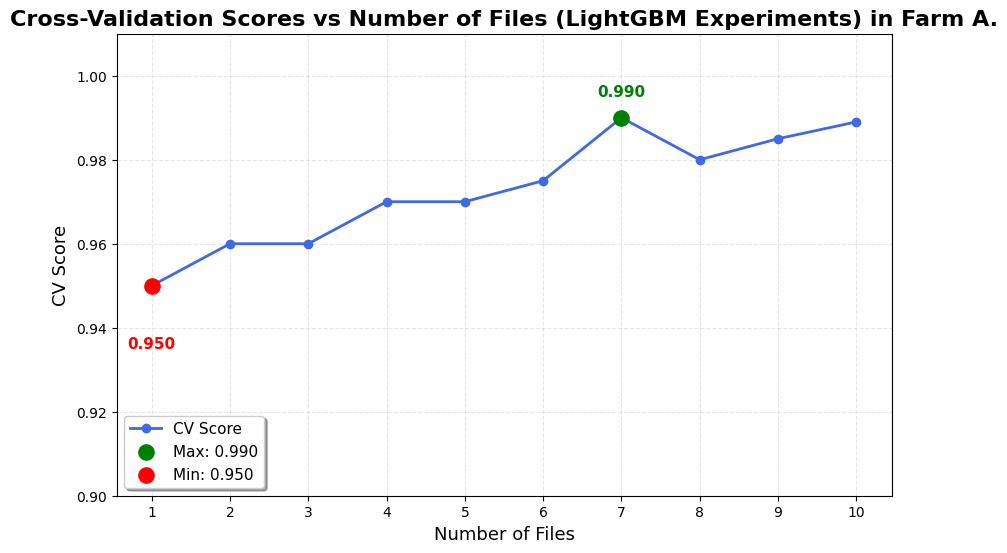

In [ ]:
Perfiles(files,cv_scores,'LightGBM','A')

In [ ]:
for i in range (2,10):

 run_model(farm_to_read=["farm_b"], n_to_read=[i], randomize=True)

Chargement et préparation des données ...
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/event_info.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/datasets/53.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/datasets/77.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/event_info.csv
combination des dataframes ...
samplage ...
nettoyage ...
filtrage ...
création labels ...
suppression colonnes inutiles ...
sélection des autres colonnes numériques ...
Gestion des valeurs manquantes ...

### Entraînement du modèle LightGBM ###
[LightGBM] [Info] Number 

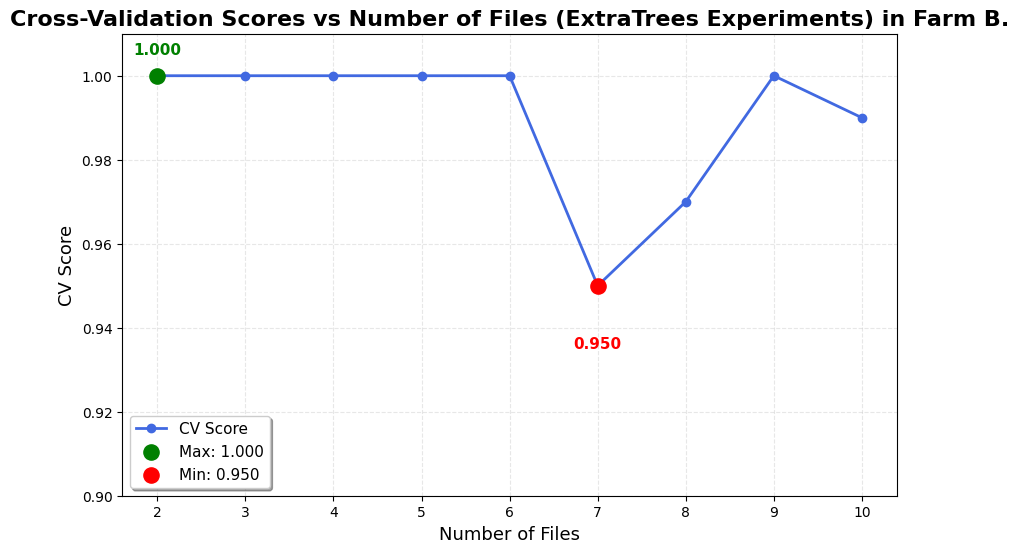

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Number of files used in different experiments (manually extracted from logs)
files = [2, 3, 4, 5, 6, 7, 8,9,10]
# Corresponding mean CV scores (from logs, all ≈ 1.0 except a few drops)
cv_scores = [1.00, 1.00, 1.00, 1.00, 1.00, 0.95, 0.97,1.00,0.99]

# # Find max and min points
# max_idx = cv_scores.index(max(cv_scores))
# min_idx = cv_scores.index(min(cv_scores))

# plt.figure(figsize=(10, 6))

# # Plot line with markers
# plt.plot(files, cv_scores, marker='o', linestyle='-', linewidth=2, color='royalblue', label="CV Score")

# # Highlight max and min
# plt.scatter(files[max_idx], cv_scores[max_idx], color='green', s=120, zorder=5, label=f"Max: {cv_scores[max_idx]:.3f}")
# plt.scatter(files[min_idx], cv_scores[min_idx], color='red', s=120, zorder=5, label=f"Min: {cv_scores[min_idx]:.3f}")

# # Annotate points
# plt.text(files[max_idx], cv_scores[max_idx]+0.005, f"{cv_scores[max_idx]:.3f}", ha='center', fontsize=11, fontweight='bold', color='green')
# plt.text(files[min_idx], cv_scores[min_idx]-0.015, f"{cv_scores[min_idx]:.3f}", ha='center', fontsize=11, fontweight='bold', color='red')

# # Titles and labels
# plt.title("Cross-Validation Scores vs Number of Files (ExtraTree Experiments)", fontsize=16, fontweight='bold')
# plt.xlabel("Number of Files", fontsize=13)
# plt.ylabel("CV Score", fontsize=13)
# plt.xticks(files)
# plt.ylim(0.90, 1.01)

# # Fancy grid and legend
# plt.grid(alpha=0.3, linestyle="--")
# plt.legend(fontsize=11, loc="lower left", frameon=True, shadow=True)

# plt.show()
Perfiles(files,cv_scores,'ExtraTrees','B')

In [ ]:
import time
for i in range (2,10):
 run_model(farm_to_read=["farm_c"], n_to_read=[i], randomize=True)

Chargement et préparation des données ...
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/event_info.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/datasets/20.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/datasets/11.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/event_info.csv
combination des dataframes ...
samplage ...
nettoyage ...
filtrage ...
création labels ...
suppression colonnes inutiles ...
sélection des autres colonnes numériques ...
Gestion des valeurs manquantes ...

### Entraînement du modèle LightGBM ###
[LightGBM] [Info] Number 

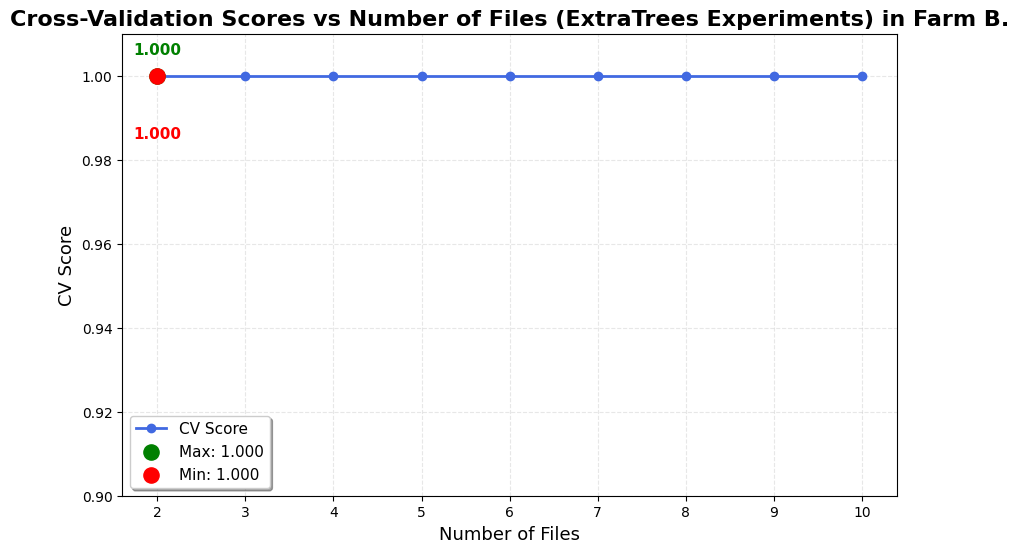

In [ ]:
Perfiles(files,cv_scores,'ExtraTrees','B')

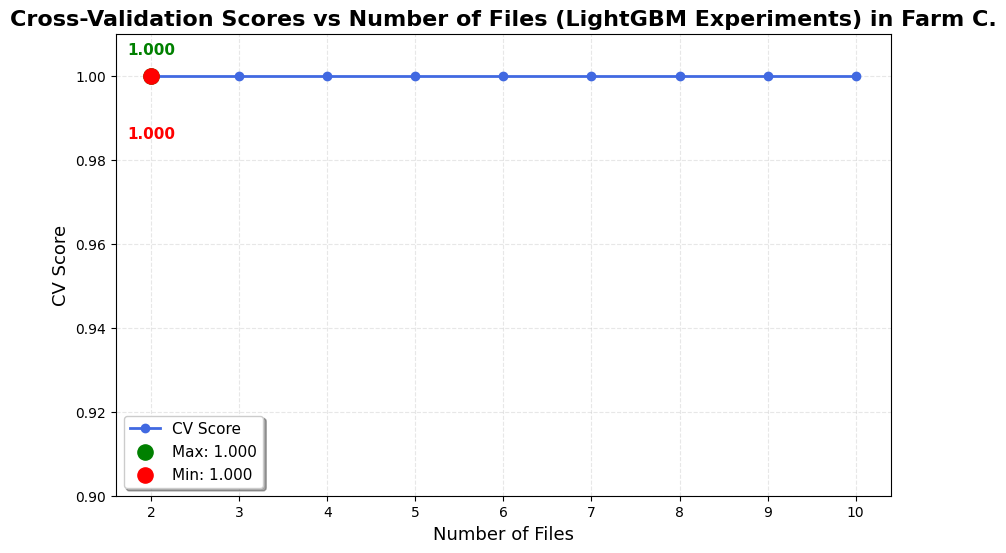

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Number of files used in different experiments (manually extracted from logs)
files = [2, 3, 4, 5, 6, 7, 8,9,10]
# Corresponding mean CV scores (from logs, all ≈ 1.0 except a few drops)
cv_scores = [1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00,1.00,1.00]

def Perfiles(files,cv_scores,Model,Farm):
# Find max and min points
 max_idx = cv_scores.index(max(cv_scores))
 min_idx = cv_scores.index(min(cv_scores))

 plt.figure(figsize=(10, 6))

# Plot line with markers
 plt.plot(files, cv_scores, marker='o', linestyle='-', linewidth=2, color='royalblue', label="CV Score")

# Highlight max and min
 plt.scatter(files[max_idx], cv_scores[max_idx], color='green', s=120, zorder=5, label=f"Max: {cv_scores[max_idx]:.3f}")
 plt.scatter(files[min_idx], cv_scores[min_idx], color='red', s=120, zorder=5, label=f"Min: {cv_scores[min_idx]:.3f}")

# Annotate points
 plt.text(files[max_idx], cv_scores[max_idx]+0.005, f"{cv_scores[max_idx]:.3f}", ha='center', fontsize=11, fontweight='bold', color='green')
 plt.text(files[min_idx], cv_scores[min_idx]-0.015, f"{cv_scores[min_idx]:.3f}", ha='center', fontsize=11, fontweight='bold', color='red')

# Titles and labels
 plt.title("Cross-Validation Scores vs Number of Files ("+Model+" Experiments) in Farm "+Farm+".", fontsize=16, fontweight='bold')
 plt.xlabel("Number of Files", fontsize=13)
 plt.ylabel("CV Score", fontsize=13)
 plt.xticks(files)
 plt.ylim(0.90, 1.01)

# Fancy grid and legend
 plt.grid(alpha=0.3, linestyle="--")
 plt.legend(fontsize=11, loc="lower left", frameon=True, shadow=True)

 plt.show()
Perfiles(files,cv_scores,'LightGBM','C')

# 2. labellisation par période

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

# Importer les modèles
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
# from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
# from catboost import CatBoostClassifier

def load_and_labelize(farm_to_read, n_to_read, randomize=True):
    # Récupérer les chemins des fichiers
    files_paths = custom_get_files_paths(farm_to_read, n_to_read, randomize, sequelize=True)

    # Lire les fichiers CSV dans des DataFrames
    dataframes = custom_read_csv(files_paths)

    # Créer des sous-ensembles basés sur les informations d'événement
    data_dict = custom_read_csv_subsets(dataframes)

    combined_event_info = get_combined_event_info()

    labeled_dataframes = label_data(dataframes, event_info=combined_event_info)
    # cette fonction récupère uniquement les périodes des dataframes entre les valeurs dans les colonnes "event_start_id" et "event_end_id" des fichiers "event_info"
    # puis elle labellise chaque ligne de cette période selon la colonne "event_label" du fichier "event_info"
    # puis renvoie un dictionnaire contenant en clé l'id du fichier csv et en valeur le dataframe correspondant à la période précisée dans "event_info", labellisé correctement

    return labeled_dataframes

# Combiner tous les DataFrames étiquetés dans un seul DataFrame
def combine_data_for_training(labeled_dataframes_dict):
    """Combine all labeled DataFrames into one big DataFrame."""
    labeled_dataframes_list = []

    for file_id, df in labeled_dataframes_dict.items():
        labeled_dataframes_list.append(df)

    # Combiner tous les DataFrames dans un seul DataFrame
    combined_df = pd.concat(labeled_dataframes_list, ignore_index=True)
    return combined_df

# Séparer les caractéristiques et les étiquettes du DataFrame combiné
def separate_features_and_labels(combined_df):
    """Sépare les caractéristiques et les étiquettes du DataFrame combiné."""
    X = combined_df.drop(columns=["time_stamp", "status_type_id", "asset_id", "id", "label", "train_test"])  # Enlever la colonne de label pour obtenir les caractéristiques
    y = combined_df['label']  # La colonne 'label' contient les étiquettes (normal ou anomaly)

    # Convertir les étiquettes en valeurs numériques (0 et 1)
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)  # "normal" -> 0, "anomaly" -> 1
    return X, y_encoded, label_encoder

def plot_feature_importance(model, X_train,ModelName):
    """
    Affiche l'importance des caractéristiques pour les modèles avec l'attribut `feature_importances_`.
    """
    if hasattr(model, "feature_importances_"):
        # Extraire les importances
        feature_importances = pd.Series(model.feature_importances_, index=X_train.columns)
        feature_importances = feature_importances.sort_values(ascending=False)

        # Limiter à 20 caractéristiques les plus importantes
        top_n = 20
        top_features = feature_importances.head(top_n)

        # Afficher un graphe
        plt.figure(figsize=(10, 6))
        top_features.plot(kind="bar", color="teal")
        plt.title(f"Feature Importance for  - {ModelName}")
        plt.xlabel("Features")
        plt.ylabel("Importance")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
    else:
        print(f"{model.__class__.__name__} n'a pas d'attribut `feature_importances_`.")
import time
# Entraîner le modèle de régression logistique
def train_and_evaluate_model(model, X, y):
    """
    Train a model with incremental feature selection based on feature importance
    and evaluate performance. Stops once mean CV accuracy reaches 0.99.
    """
    import time
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from sklearn.model_selection import train_test_split, cross_val_score
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

    # Drop NaN rows
    X = X.fillna(method='bfill')
    y = y#.loc[X.index]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )
    columns = X_train.columns

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=columns)

    # Initial training
    start_time = time.time()
    model.fit(X_train_scaled, y_train)
    training_time = time.time() - start_time

    start_time = time.time()
    y_pred = model.predict(X_test_scaled)
    testing_time = time.time() - start_time

    print(f"Training time : {training_time:.2f} seconds")
    print(f"Testing time  : {testing_time:.2f} seconds")

    # Base metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary', pos_label=1)
    recall = recall_score(y_test, y_pred, average='binary', pos_label=1)
    f1 = f1_score(y_test, y_pred, average='binary', pos_label=1)

    print(f"\nBase model performance on full feature set:")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1-Score: {f1:.2f}")

    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    print(f"CV Scores: {cv_scores}")
    print(f"Mean CV Score: {cv_scores.mean():.2f}")

    # # Feature Importances
    # try:
    #     importances = model.feature_importances_
    # except AttributeError:
    #     raise ValueError("This model does not support feature_importances_ attribute.")

    # feature_importances = pd.DataFrame({
    #     "Feature": columns,
    #     "Importance": importances
    # }).sort_values(by="Importance", ascending=False)

    # # Incremental feature tracking
    # features_used = []
    # mean_cv_scores = []
    # stop_threshold = 0.99
    # stop_reached = False

    # for i in range(1, len(feature_importances) + 1):
    #     selected_features = feature_importances["Feature"].iloc[:i].tolist()
    #     X_train_subset = X_train_scaled[selected_features]

    #     # Cross-validation on subset of features
    #     cv_subset_scores = cross_val_score(model, X_train_subset, y_train, cv=5, scoring='accuracy')
    #     mean_score = cv_subset_scores.mean()

    #     features_used.append(i)
    #     mean_cv_scores.append(mean_score)

    #     print(f"Top {i} features -> Mean CV Accuracy: {mean_score:.4f}")

    #     # Early stopping
    #     if mean_score >= stop_threshold:
    #         print(f"✅ Early stopping reached: accuracy {mean_score:.4f} with {i} features.")
    #         stop_reached = True
    #         break

    # # Plot accuracy vs number of features
    # plt.figure(figsize=(8, 5))
    # plt.plot(features_used, mean_cv_scores, marker="o", linestyle="-", color="b")
    # plt.axhline(y=stop_threshold, color="r", linestyle="--", label="Target Accuracy (0.99)")
    # plt.xlabel("Number of Features")
    # plt.ylabel("Mean CV Accuracy")
    # plt.title(f"Incremental Feature Selection ({model.__class__.__name__})")
    # plt.legend()
    # plt.grid(True)
    # plt.show()

    return model, scaler#, feature_importances, pd.DataFrame({
       # "Num_Features": features_used,
       # "Mean_CV_Accuracy": mean_cv_scores
    #}), stop_reached


def logistic_regression_pipeline(labeled_data_dict):
    """Pipeline complet pour tester chaque modèle individuellement."""
    # Combiner les données étiquetées en un seul DataFrame
    combined_df = combine_data_for_training(labeled_data_dict)

    # Séparer les caractéristiques et les étiquettes
    X, y, label_encoder = separate_features_and_labels(combined_df)

    # Liste des modèles à tester
    models = {
       # "Random Forest": RandomForestClassifier(n_estimators=50, random_state=42),
        #"XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        #"LightGBM": LGBMClassifier(random_state=42),
        #"CatBoost": CatBoostClassifier(silent=True, random_state=42),
        "Extra Trees": ExtraTreesClassifier(n_estimators=50, random_state=42),
        #"Gradient Boosting": GradientBoostingClassifier(n_estimators=50, random_state=42),
        #"Decision Tree": DecisionTreeClassifier(random_state=42)
    }

    # Tester chaque modèle
    for model_name, model in models.items():
        print(f"\n### Entraînement du modèle {model_name} ###")
        model, scaler = train_and_evaluate_model(model, X, y)

## Farm A : période

In [ ]:
for i in range (2,10):
 labeled_data_A = load_and_labelize(farm_to_read=["farm_a"], n_to_read=[i], randomize=True)
 logistic_regression_pipeline(labeled_data_A)

Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/event_info.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/datasets/25.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/datasets/68.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/event_info.csv
Labeling D

/tmp/ipython-input-3066986960.py:98: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = X.fillna(method='bfill')
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:01:28] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training time : 1.88 seconds
Testing time  : 0.03 seconds

Base model performance on full feature set:
Accuracy: 1.00
Precision: 0.99
Recall: 1.00
F1-Score: 1.00


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:01:30] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:01:32] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:01:32] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:01:33] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:01:33] WARNING: /w

CV Scores: [0.99075786 1.         0.99444444 1.         0.9962963 ]
Mean CV Score: 1.00
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/event_info.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/datasets/25.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/datasets/68.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/datasets/22.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/event_info.csv
Event info file successfully read

...

CV Scores: [0.98253724 0.99178223 0.99126413 0.99177801 0.99075026]
Mean CV Score: 0.99
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/event_info.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/datasets/25.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/datasets/69.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/datasets/13.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/datasets/24.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/datasets/68.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/datasets/22.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/datasets/72.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm 

/tmp/ipython-input-3066986960.py:98: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = X.fillna(method='bfill')
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:03:02] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training time : 1.40 seconds
Testing time  : 0.02 seconds

Base model performance on full feature set:
Accuracy: 0.99
Precision: 1.00
Recall: 0.99
F1-Score: 0.99


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:03:03] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:03:05] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:03:06] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:03:07] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:03:08] WARNING: /w

CV Scores: [0.99057451 0.99012567 0.99147217 0.99192101 0.98967684]
Mean CV Score: 0.99


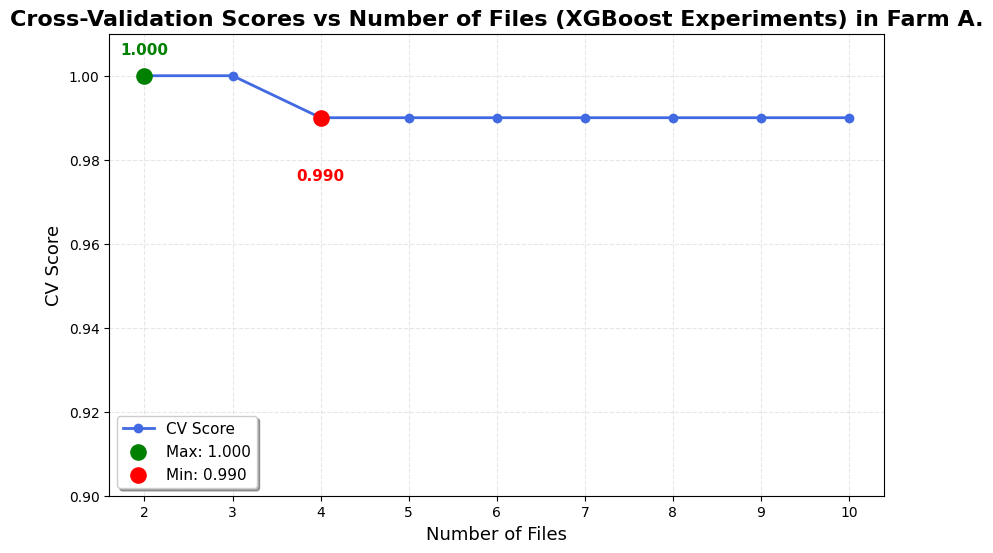

In [ ]:
# Number of files used in different experiments
files = [2, 3, 4, 5, 6, 7, 8, 9, 10]

# Corresponding mean CV scores
cv_scores = [1.00, 1.00, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99]
Perfiles(files,cv_scores,'XGBoost','A')

## Farm B : période

In [ ]:
for i in range (2,10):
 labeled_data_B = load_and_labelize(farm_to_read=["farm_b"], n_to_read=[i], randomize=True)
 logistic_regression_pipeline(labeled_data_B)

Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/event_info.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/datasets/83.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/datasets/34.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/event_info.csv
Labeling D

/tmp/ipython-input-3066986960.py:98: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = X.fillna(method='bfill')
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:03:17] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training time : 1.89 seconds
Testing time  : 0.03 seconds

Base model performance on full feature set:
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1-Score: 1.00


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:03:19] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:03:21] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:03:22] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:03:24] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:03:26] WARNING: /w

CV Scores: [0.99868363 0.99956102 0.99912204 1.         1.        ]
Mean CV Score: 1.00
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/event_info.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/datasets/83.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/datasets/34.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/datasets/7.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/event_info.csv
Event info file successfully read:

...

CV Scores: [0.99947497 1.         0.99982499 0.99964998 1.        ]
Mean CV Score: 1.00
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/event_info.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/datasets/83.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/datasets/52.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/datasets/21.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/datasets/2.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/datasets/34.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/datasets/7.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/datasets/53.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/

/tmp/ipython-input-3066986960.py:98: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = X.fillna(method='bfill')
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:08:23] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training time : 7.28 seconds
Testing time  : 0.06 seconds

Base model performance on full feature set:
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1-Score: 1.00


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:08:29] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:08:39] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:08:45] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:08:54] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:09:00] WARNING: /w

CV Scores: [1.         0.99983652 0.99967304 1.         1.        ]
Mean CV Score: 1.00


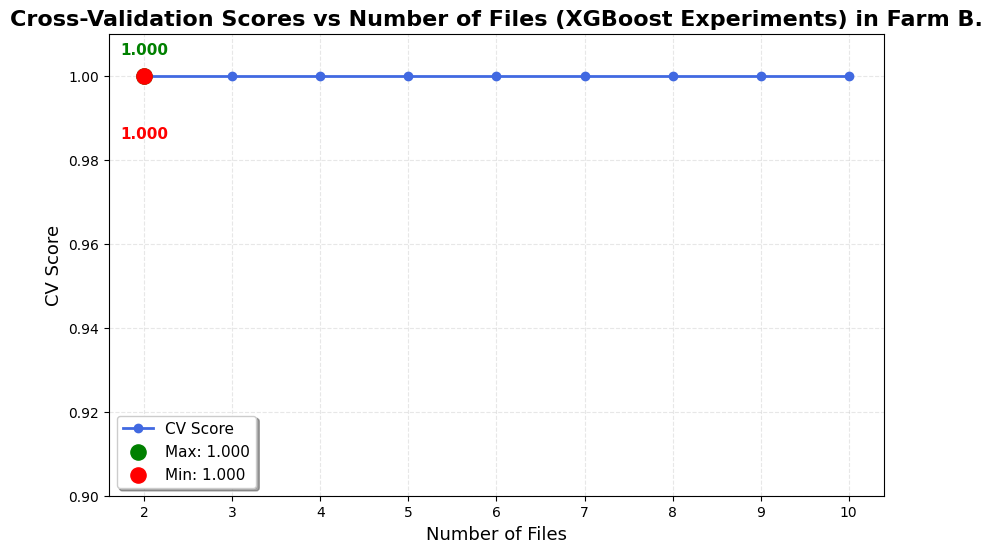

In [ ]:
# Number of files used in different experiments
# files = [2, 3, 4, 5, 6, 7, 8, 9, 10]

# Corresponding mean CV scores
cv_scores = [1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00]
Perfiles(files,cv_scores,'XGBoost','B')


### Entraînement du modèle XGBoost ###


/tmp/ipython-input-3916470795.py:98: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = X.fillna(method='bfill')
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:11:05] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training time : 4.78 seconds
Testing time  : 0.04 seconds

Base model performance on full feature set:
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1-Score: 1.00


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:11:10] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:11:12] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:11:15] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:11:20] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:11:23] WARNING: /w

CV Scores: [1.         0.99944893 0.99908156 0.99963262 0.99963262]
Mean CV Score: 1.00


...

Top 13 features -> Mean CV Accuracy: 0.9865


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:11:44] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:11:44] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:11:44] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:11:45] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:11:45] WARNING: /w

Top 14 features -> Mean CV Accuracy: 0.9882


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:11:45] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:11:46] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:11:46] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:11:46] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:11:46] WARNING: /w

Top 15 features -> Mean CV Accuracy: 0.9901
✅ Early stopping reached: accuracy 0.9901 with 15 features.


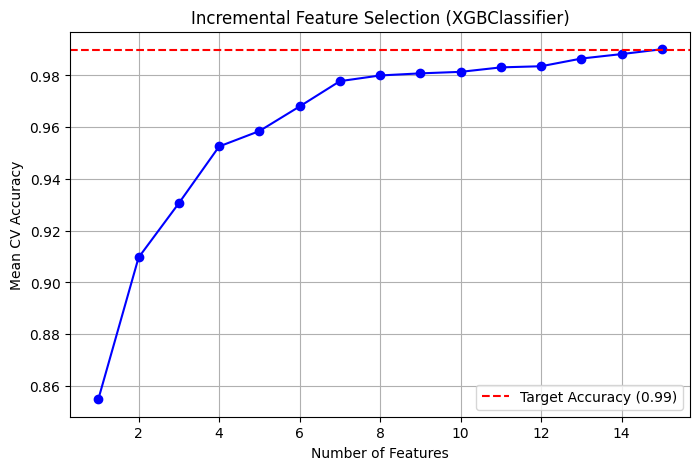

ValueError: too many values to unpack (expected 2)

In [ ]:
# logistic_regression_pipeline(labeled_data_B)

## Farm C : période

In [ ]:
for i in range (2,10):
 labeled_data_C=load_and_labelize(farm_to_read=["farm_c"], n_to_read=[i], randomize=True)
 model = logistic_regression_pipeline(labeled_data_C)

Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/event_info.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/datasets/8.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/datasets/12.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/event_info.csv
Labeling Da

/tmp/ipython-input-2312467660.py:98: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = X.fillna(method='bfill')


Training time : 0.35 seconds
Testing time  : 0.02 seconds

Base model performance on full feature set:
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1-Score: 1.00
CV Scores: [1. 1. 1. 1. 1.]
Mean CV Score: 1.00
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/event_info.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/datasets/8.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/datasets/12.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/datasets/4.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/event_info.csv
Event info fil

/tmp/ipython-input-2312467660.py:98: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = X.fillna(method='bfill')


Training time : 0.50 seconds
Testing time  : 0.02 seconds

Base model performance on full feature set:
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1-Score: 1.00
CV Scores: [1. 1. 1. 1. 1.]
Mean CV Score: 1.00
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/event_info.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/datasets/8.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/datasets/6.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/datasets/12.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/datasets/4.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm A/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm B/event_info.csv
Event info file successfu

...

Training time : 1.71 seconds
Testing time  : 0.05 seconds

Base model performance on full feature set:
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1-Score: 1.00
CV Scores: [1. 1. 1. 1. 1.]
Mean CV Score: 1.00
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/event_info.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/datasets/8.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/datasets/6.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/datasets/36.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/datasets/32.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/datasets/12.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/datasets/4.csv
File successfully read: /content/drive/MyDriv

/tmp/ipython-input-2312467660.py:98: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = X.fillna(method='bfill')


Training time : 2.19 seconds
Testing time  : 0.08 seconds

Base model performance on full feature set:
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1-Score: 1.00
CV Scores: [1. 1. 1. 1. 1.]
Mean CV Score: 1.00
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/event_info.csv
Event info file successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/event_info.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/datasets/8.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/datasets/6.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/datasets/36.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/datasets/32.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/datasets/12.csv
File successfully read: /content/drive/MyDrive/CARE_To_Compare/Wind Farm C/datasets/4.csv
File successfully read: /content/drive/MyDriv

/tmp/ipython-input-2312467660.py:98: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = X.fillna(method='bfill')


Training time : 3.44 seconds
Testing time  : 0.09 seconds

Base model performance on full feature set:
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1-Score: 1.00
CV Scores: [0.99963424 1.         1.         1.         1.        ]
Mean CV Score: 1.00


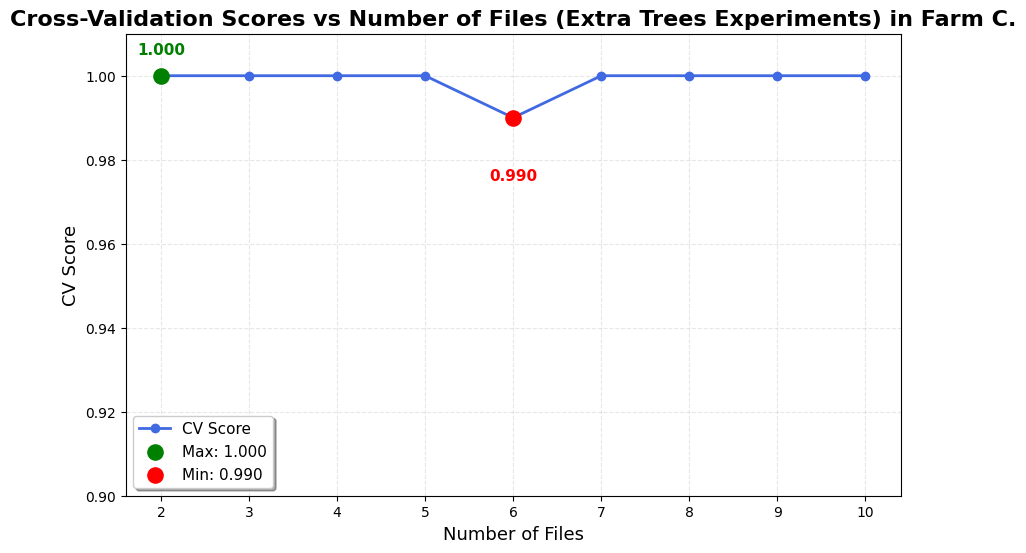

In [ ]:
# model = logistic_regression_pipeline(labeled_data_C)
# Corresponding mean CV scores
cv_scores = [1.00, 1.00, 1.00, 1.00, 0.99, 1.00, 1.00, 1.00, 1.00]
Perfiles(files,cv_scores,'Extra Trees','C')